# WQD7013 Final Project

**Dataset A (corrected): Diabetes 130-US Hospitals for Years 1999–2008** (UCI ML Repository; Strack et al. 2014, CC BY 4.0)

**Primary question.** *What patient characteristics, clinical complexity indicators, and diabetes management factors best predict early hospital readmission (within 30 days), and does the effect of HbA1c measurement on readmission risk differ across admission types?*

# 1. Dataset Audit & Exploratory Analysis


**Classification decisions used throughout (justified in §1.1b):**
- `age` (10-year bins) → **midpoint-numeric** (continuous).
- `A1Cresult`, `max_glu_serum` → **ordinal** with an explicit `Not measured` level ("test not ordered" is a clinical state, not missing).
- `time_in_hospital` → **discrete count, analysed as continuous** (CLT justified by large n).
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id` → **nominal**, decoded via `IDS_mapping.csv`.

In [4]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 60)

# --- read dataset directly from GitHub ---
GITHUB_RAW = "https://raw.githubusercontent.com/unluckytau/WQD7013-Final-Project/refs/heads/main/dataset"
DATA = f"{GITHUB_RAW}/diabetic_data.csv"
MAP  = f"{GITHUB_RAW}/IDS_mapping.csv"
print("Loading:", DATA)

Loading: https://raw.githubusercontent.com/unluckytau/WQD7013-Final-Project/refs/heads/main/dataset/diabetic_data.csv


## 1.1 Structural Audit & Variable Classification

In [5]:
# Load — missing values are the literal '?' (NOT blank cells)
df = pd.read_csv(DATA, na_values="?", low_memory=False)
print(f"Shape: {df.shape[0]:,} encounters x {df.shape[1]} variables")
print(f"Unique patients: {df['patient_nbr'].nunique():,}  |  max encounters per patient: {df['patient_nbr'].value_counts().max()}")
df.head(3)

Shape: 101,766 encounters x 50 variables
Unique patients: 71,518  |  max encounters per patient: 40


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [6]:
import urllib.request

def load_map(path):
    if str(path).startswith("http"):
        text = urllib.request.urlopen(path).read().decode("utf-8")
    else:
        with open(path) as f:
            text = f.read()

    maps, cur = {}, None
    for line in text.splitlines():
        if line.endswith(",description"):
            cur = line.split(",")[0]
            maps[cur] = {}
        elif cur and "," in line and line.strip(","):
            k = line.split(",")[0].strip()
            v = line.split(",", 1)[1].strip().strip('"')
            if k.isdigit():
                maps[cur][int(k)] = v
    return maps

maps = load_map(MAP)
for col in ["admission_type_id", "discharge_disposition_id", "admission_source_id"]:
    df[col + "_label"] = df[col].map(maps[col]).fillna("Unknown")

### 1.1(a) Variable inventory table
Each variable classified by inferred dtype, corrected type, measurement level, and role in the primary (readmission) question.

In [7]:
inventory = [
 ("encounter_id","int64","int","discrete","Identifier (drop)"),
 ("patient_nbr","int64","int","discrete","Identifier / clustering key"),
 ("race","object","category","nominal","Confounder"),
 ("gender","object","category","nominal","Predictor"),
 ("age","object","ordinal bins -> midpoint","ordinal/continuous","Predictor"),
 ("weight","object","mostly missing","continuous(bins)","Irrelevant (~97% missing)"),
 ("admission_type_id","int64","category (coded)","nominal","Predictor / moderator"),
 ("discharge_disposition_id","int64","category (coded)","nominal","Predictor (filter death/hospice)"),
 ("admission_source_id","int64","category (coded)","nominal","Predictor"),
 ("time_in_hospital","int64","int","discrete->continuous","OUTCOME (Part 3)"),
 ("payer_code","object","category","nominal","Irrelevant/admin (~40% missing)"),
 ("medical_specialty","object","category","nominal","Confounder (~49% missing)"),
 ("num_lab_procedures","int64","int","discrete","Predictor (complexity)"),
 ("num_procedures","int64","int","discrete","Predictor (complexity)"),
 ("num_medications","int64","int","discrete","Predictor (complexity)"),
 ("number_outpatient","int64","int","discrete","Predictor (prior utilisation)"),
 ("number_emergency","int64","int","discrete","Predictor (prior utilisation)"),
 ("number_inpatient","int64","int","discrete","Predictor (strong)"),
 ("diag_1","object","ICD-9 -> 9 groups","nominal","Predictor (primary dx)"),
 ("diag_2","object","ICD-9 -> 9 groups","nominal","Predictor"),
 ("diag_3","object","ICD-9 -> 9 groups","nominal","Predictor"),
 ("number_diagnoses","int64","int","discrete","Predictor (severity)"),
 ("max_glu_serum","object","ordinal + Not measured","ordinal","Predictor"),
 ("A1Cresult","object","ordinal + Not measured","ordinal","KEY predictor (HbA1c)"),
 ("metformin ... metformin-pioglitazone (24 drug cols)","object","ordinal (No/Steady/Up/Down)","ordinal","Predictors (Lasso, Part 5)"),
 ("change","object","binary","nominal","Predictor"),
 ("diabetesMed","object","binary","nominal","Predictor"),
 ("readmitted","object","3-level -> binary <30","ordinal/nominal","Source of binary OUTCOME (Part 4)"),
]
inv = pd.DataFrame(inventory, columns=["variable","inferred_dtype","corrected_type","measurement_level","role"])
inv

,variable,inferred_dtype,corrected_type,measurement_level,role
0,encounter_id,int64,int,discrete,Identifier (drop)
1,patient_nbr,int64,int,discrete,Identifier / clustering key
2,race,object,category,nominal,Confounder
3,gender,object,category,nominal,Predictor
4,age,object,ordinal bins -> midpoint,ordinal/continuous,Predictor
5,weight,object,mostly missing,continuous(bins),Irrelevant (~97% missing)
6,admission_type_id,int64,category (coded),nominal,Predictor / moderator
7,discharge_disposition_id,int64,category (coded),nominal,Predictor (filter death/hospice)
8,admission_source_id,int64,category (coded),nominal,Predictor
9,time_in_hospital,int64,int,discrete->continuous,OUTCOME (Part 3)


### 1.1(b) Ambiguous classifications — defence

**`age` (stored as 10-year bins).** Inferred dtype is `object`; the correct measurement level is ambiguous between *ordinal* and *continuous*. We treat it as **continuous via bin midpoints** ([70-80)→75). Justification: the bins are equal-width and monotone, so the midpoint is an unbiased representative of each interval under a uniform-within-bin assumption; this lets age enter regression as a **single interpretable slope** (years), preserves statistical power, and avoids spending 9 degrees of freedom on dummies. *Consequence of misclassification:* treating the raw bin index as a plain number is the same midpoint logic but mislabels the unit; treating age as unordered **nominal** would discard the ordering and inflate model complexity, while forcing it ordinal with rank scores (1–10) imposes equal spacing on an arbitrary scale and makes the coefficient uninterpretable in years.

**`A1Cresult` / `max_glu_serum`.** Ambiguity is two-fold: (i) ordinal vs nominal, and (ii) whether the dominant level is "missing". We treat them as **ordinal** (`Norm` < `>7` < `>8`; `Norm` < `>200` < `>300`) with an explicit **`Not measured`** level. Justification: the levels are clinically ordered severities, and the question targets the *effect of HbA1c measurement* — so whether the test was ordered is itself informative and must be retained, not deleted. *Consequence of misclassification:* counting `Not measured` (83% of `A1Cresult`) as missing would trigger near-total listwise deletion or nonsensical imputation and destroy the central HbA1c signal; ignoring the ordering would forgo the dose–response interpretation the primary question depends on.

### 1.1(c) Missing-data audit + mechanism classification

,n_missing,pct_missing
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


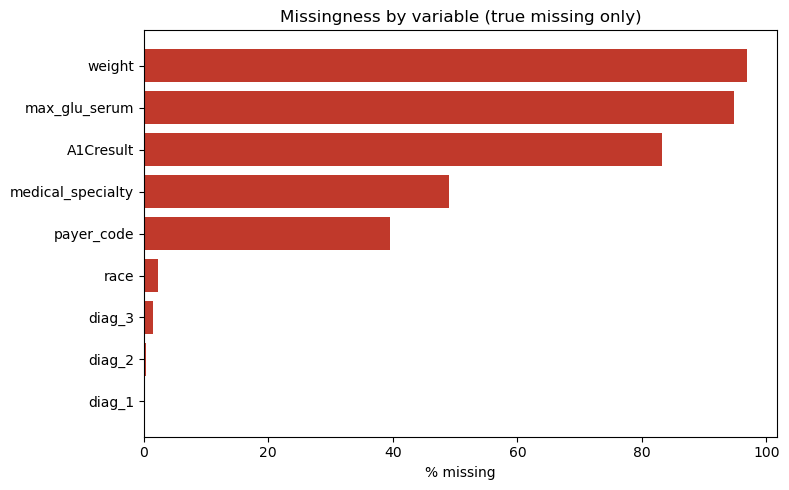

In [8]:
miss = pd.DataFrame({"n_missing": df.isna().sum(),
                     "pct_missing": (df.isna().mean()*100).round(2)})
miss = miss[miss.n_missing > 0].sort_values("pct_missing", ascending=False)
display(miss)

plt.figure(figsize=(8,5))
plt.barh(miss.index[::-1], miss.pct_missing[::-1], color="#c0392b")
plt.xlabel("% missing"); plt.title("Missingness by variable (true missing only)")
plt.tight_layout(); plt.show()

In [9]:
# MAR test: does medical_specialty missingness depend on admission type?
df["medspec_missing"] = df["medical_specialty"].isna().astype(int)
ct = pd.crosstab(df["admission_type_id_label"], df["medspec_missing"])
chi2, p_ms, dof, _ = stats.chi2_contingency(ct)
print(f"medical_specialty missingness vs admission type: chi2={chi2:.1f}, dof={dof}, p={p_ms:.2e}")

# MNAR evidence: weight-missing patients differ in severity (number_diagnoses)?
df["weight_missing"] = df["weight"].isna().astype(int)
g1 = df.loc[df.weight_missing==1, "number_diagnoses"]; g0 = df.loc[df.weight_missing==0, "number_diagnoses"]
t_w, p_w = stats.ttest_ind(g1, g0, equal_var=False)
print(f"number_diagnoses: weight-missing mean={g1.mean():.2f} vs recorded mean={g0.mean():.2f}, Welch p={p_w:.2e}")

medical_specialty missingness vs admission type: chi2=9228.1, dof=7, p=0.00e+00
number_diagnoses: weight-missing mean=7.40 vs recorded mean=7.98, Welch p=2.29e-89


**Mechanism classification (variables >5% missing):**

- **`weight` (96.9%) → MNAR.** Recording is tied to clinical workflow/severity; weight-missing encounters have significantly *fewer* diagnoses (7.40 vs 7.98, p≈10⁻⁸⁹), so missingness depends on patient state. Effectively unusable — drop.
- **`medical_specialty` (49.1%) → MAR.** Missingness is strongly associated with admission type (χ²≈9228, df=7, p<0.001), i.e. it depends on an *observed* variable. Can be modelled with a `Missing` indicator category.
- **`payer_code` (39.6%) → MAR/MCAR-leaning, administrative.** Reflects billing/data-entry, not clinical state; not a predictor of interest. Retain as `Unknown` category or drop.
- `race` (2.2%), `diag_3` (1.4%), `diag_2`/`diag_1` (<0.5%) are below the 5% threshold; handle with an explicit `Unknown`/`Other` category.

### 1.1(d) [JUSTIFY] Handling the two highest-missing variables

In [10]:
# weight parsed to numeric midpoints to compare imputation strategies numerically
def wmid(x):
    if pd.isna(x): return np.nan
    x = x.strip("[]()").replace(">","").replace("<","")
    if "-" in x:
        a,b = x.split("-"); return (float(a)+float(b))/2
    try: return float(x)
    except: return np.nan
df["weight_mid"] = df["weight"].apply(wmid)
w = df["weight_mid"]
comp = pd.DataFrame({
 "strategy":["Listwise (observed only)","Mean imputation","Median imputation"],
 "n_used":[int(w.notna().sum()), len(w), len(w)],
 "mean":[w.dropna().mean(), w.fillna(w.mean()).mean(), w.fillna(w.median()).mean()],
 "std":[w.dropna().std(), w.fillna(w.mean()).std(), w.fillna(w.median()).std()],
}).round(2)
display(comp)
print("medical_specialty: 49% missing -> compare drop vs 'Missing' indicator category")
print(df["medical_specialty"].fillna("Missing").value_counts().head(6))

,strategy,n_used,mean,std
0,Listwise (observed only),3197,86.27,26.03
1,Mean imputation,101766,86.27,4.61
2,Median imputation,101766,87.46,4.62


medical_specialty: 49% missing -> compare drop vs 'Missing' indicator category
medical_specialty
Missing                   49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
Name: count, dtype: int64


**[JUSTIFY] Decision.** The two highest-missing variables are `weight` (96.9%) and `medical_specialty` (49.1%).

*`weight`:* Only 3,197 of 101,766 values are observed. **Listwise deletion** would discard 97% of the data — catastrophic. **Mean/median imputation** is worse than useless here: filling 96.9% of rows with one constant collapses the standard deviation from **26.03** (observed) to **≈4.6**, manufacturing false precision and destroying any real variance — and because the mechanism is **MNAR**, the imputed values are systematically biased. **Multiple imputation** is not defensible either: with 97% missing there is essentially no observed information to build a donor model on, and MNAR violates MI's MAR assumption. **Final choice: drop `weight` entirely** and document it as an MNAR limitation.

*`medical_specialty`:* At 49% missing and **MAR**, deletion would halve the sample and bias it toward admission types that record specialty. The principled choice is to **retain it with an explicit `Missing` category** (a "missing-indicator" approach), which preserves all rows and lets the model learn whether *having an unrecorded specialty* is itself predictive — appropriate because missingness here depends on observed admission type.

## 1.2 Univariate Distributions

In [11]:
CONT = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
        "number_outpatient","number_emergency","number_inpatient","number_diagnoses"]
def describe(s):
    s = s.dropna()
    return pd.Series({"mean":s.mean(),"median":s.median(),"sd":s.std(),
        "IQR":s.quantile(.75)-s.quantile(.25),"skew":s.skew(),
        "exc_kurtosis":s.kurtosis(),"p5":s.quantile(.05),"p95":s.quantile(.95)})
uni = df[CONT].apply(describe).T.round(2)
uni

,mean,median,sd,IQR,skew,exc_kurtosis,p5,p95
time_in_hospital,4.40,4.0,2.99,4.0,1.13,0.85,1.0,11.0
num_lab_procedures,43.10,44.0,19.67,26.0,-0.24,-0.25,4.0,73.0
num_procedures,1.34,1.0,1.71,2.0,1.32,0.86,0.0,5.0
num_medications,16.02,15.0,8.13,10.0,1.33,3.47,6.0,31.0
number_outpatient,0.37,0.0,1.27,0.0,8.83,147.91,0.0,2.0
number_emergency,0.20,0.0,0.93,0.0,22.86,1191.69,0.0,1.0
number_inpatient,0.64,0.0,1.26,1.0,3.61,20.72,0.0,3.0
number_diagnoses,7.42,8.0,1.93,3.0,-0.88,-0.08,4.0,9.0


### 1.2(b) Histograms + Freedman–Diaconis bin count

time_in_hospital: n=101,766, IQR=4.0, bin width h=2*IQR/n^(1/3)=0.171 -> 76 bins
num_medications: n=101,766, IQR=10.0, bin width h=2*IQR/n^(1/3)=0.428 -> 187 bins
num_lab_procedures: n=101,766, IQR=26.0, bin width h=2*IQR/n^(1/3)=1.114 -> 118 bins


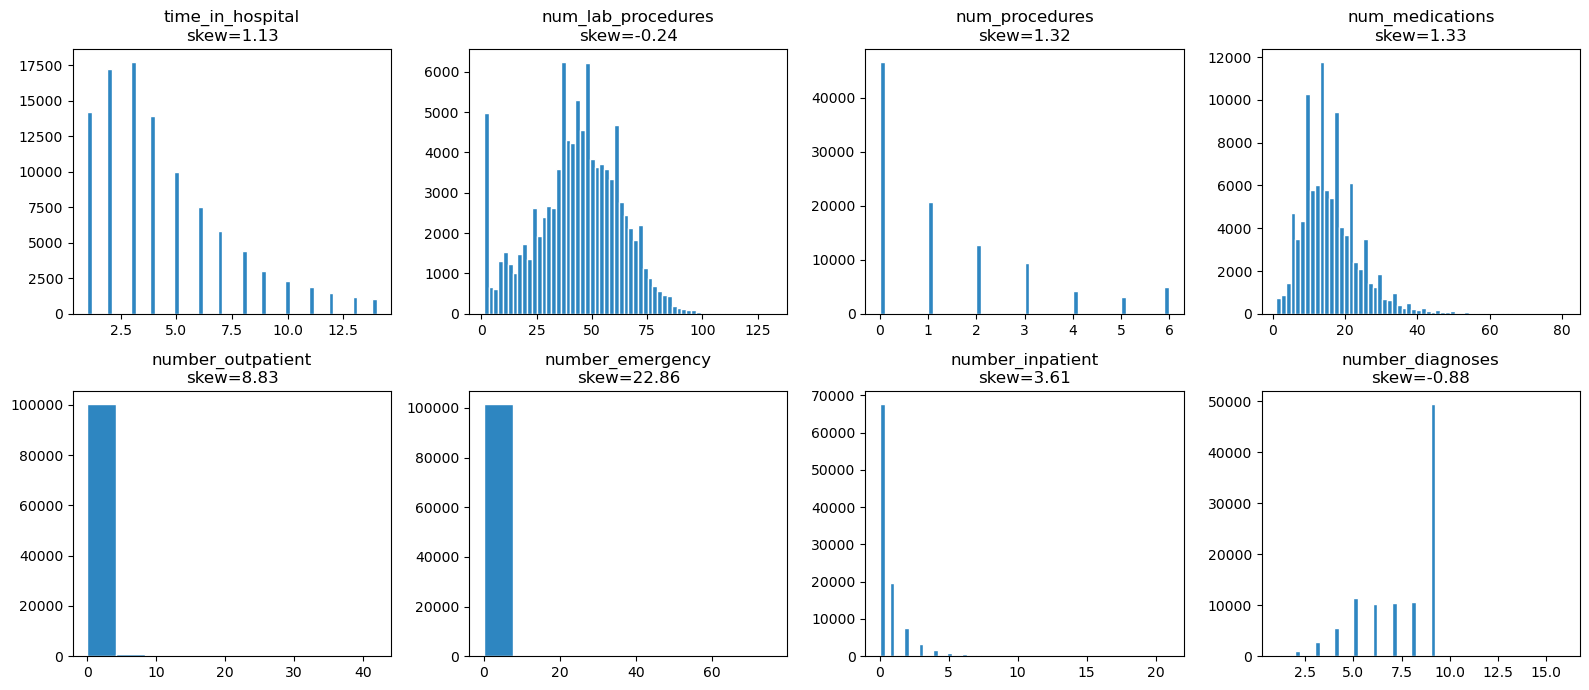

In [12]:
def fd_bins(s):
    s = s.dropna(); n = len(s); iqr = s.quantile(.75)-s.quantile(.25)
    h = 2*iqr/(n**(1/3)); k = int(np.ceil((s.max()-s.min())/h)) if h>0 else 10
    return n, iqr, h, k
for c in ["time_in_hospital","num_medications","num_lab_procedures"]:
    n,iqr,h,k = fd_bins(df[c])
    print(f"{c}: n={n:,}, IQR={iqr:.1f}, bin width h=2*IQR/n^(1/3)={h:.3f} -> {k} bins")

fig,axes = plt.subplots(2,4,figsize=(16,7))
for ax,c in zip(axes.ravel(), CONT):
    s = df[c].dropna(); _,_,_,k = fd_bins(s)
    ax.hist(s, bins=min(k,60), color="#2e86c1", edgecolor="white")
    ax.set_title(f"{c}\nskew={s.skew():.2f}")
plt.tight_layout(); plt.show()

### 1.2(c) [JUSTIFY] Outcome distribution & transformation

Shapiro-Wilk (n=5000 subsample): W=0.8857, p=1.76e-51
Kolmogorov-Smirnov: D=0.1729, p=0.00e+00
skewness raw  : 1.134
skewness sqrt : 0.474
skewness log  : -0.204


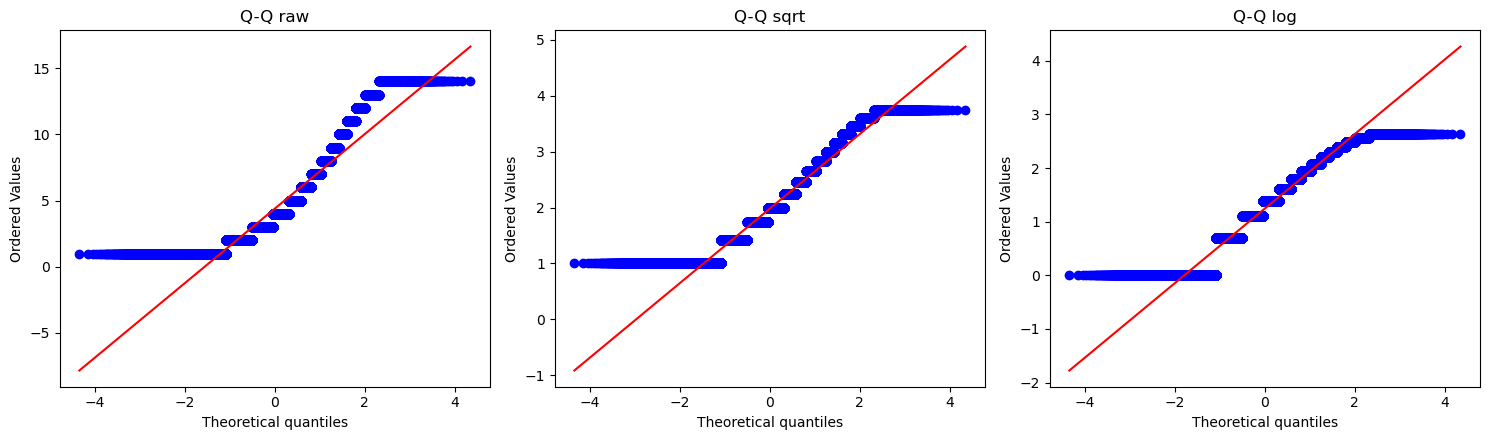

In [13]:
y = df["time_in_hospital"].astype(float)
W,pW = stats.shapiro(y.sample(5000, random_state=1))
D,pD = stats.kstest((y-y.mean())/y.std(), "norm")
print(f"Shapiro-Wilk (n=5000 subsample): W={W:.4f}, p={pW:.2e}")
print(f"Kolmogorov-Smirnov: D={D:.4f}, p={pD:.2e}")
for label, t in [("raw",y),("sqrt",np.sqrt(y)),("log",np.log(y))]:
    print(f"skewness {label:5s}: {pd.Series(t).skew():.3f}")

fig,ax = plt.subplots(1,3,figsize=(15,4.5))
for a,(lab,t) in zip(ax,[("raw",y),("sqrt",np.sqrt(y)),("log",np.log(y))]):
    stats.probplot(t,dist="norm",plot=a); a.set_title(f"Q-Q {lab}")
plt.tight_layout(); plt.show()

### 1.2(d) Categorical frequencies & rare categories (<30)

In [14]:
CAT = ["race","gender","age","A1Cresult","max_glu_serum","change","diabetesMed",
       "admission_type_id_label","readmitted"]
for c in CAT:
    vc = df[c].value_counts(dropna=False)
    prop = (vc/len(df)*100).round(2)
    print(f"\n=== {c} ===")
    print(pd.DataFrame({"count":vc,"pct":prop}).to_string())
print("\nRare categories (<30 obs):")
for c in CAT:
    vc = df[c].value_counts(dropna=False); rr = vc[vc<30]
    if len(rr): print(" ", c, dict(rr))


=== race ===
                 count    pct
race                         
Caucasian        76099  74.78
AfricanAmerican  19210  18.88
NaN               2273   2.23
Hispanic          2037   2.00
Other             1506   1.48
Asian              641   0.63

=== gender ===
                 count    pct
gender                       
Female           54708  53.76
Male             47055  46.24
Unknown/Invalid      3   0.00

=== age ===
          count    pct
age                   
[70-80)   26068  25.62
[60-70)   22483  22.09
[50-60)   17256  16.96
[80-90)   17197  16.90
[40-50)    9685   9.52
[30-40)    3775   3.71
[90-100)   2793   2.74
[20-30)    1657   1.63
[10-20)     691   0.68
[0-10)      161   0.16

=== A1Cresult ===
           count    pct
A1Cresult              
NaN        84748  83.28
>8          8216   8.07
Norm        4990   4.90
>7          3812   3.75

=== max_glu_serum ===
               count    pct
max_glu_serum              
NaN            96420  94.75
Norm            2597 

**Rare-category handling.** Only two variables have categories below 30 observations: `gender` = *Unknown/Invalid* (n=3) and `admission_type_id` = *Trauma Center* (n=21) and *Newborn* (n=10). Decision: **drop** the 3 `Unknown/Invalid` gender rows (data error, negligible loss); **collapse** the tiny admission-type levels into an `Other` group when building the grouped admission-type predictor, so no model estimates a coefficient from <30 cases (which would be high-variance and unstable).

## 1.3 Bivariate Relationships

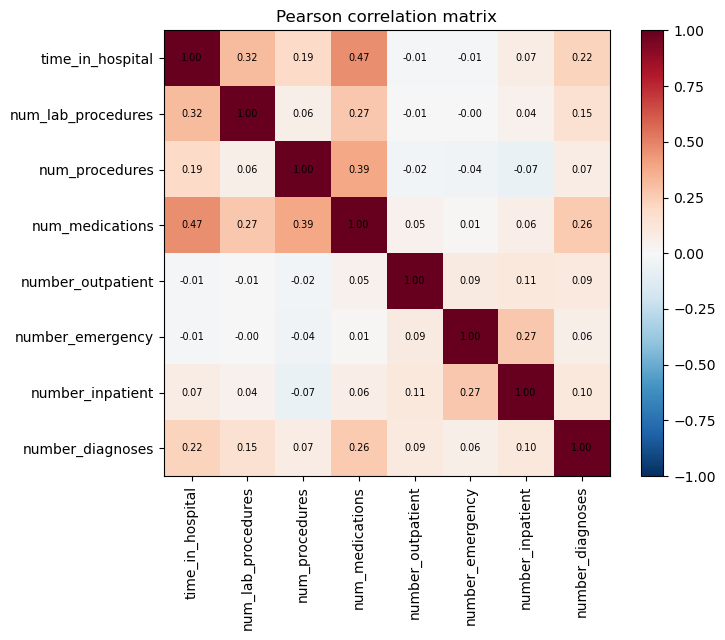

Top-3 |r| pairs (Pearson vs Spearman):
  time_in_hospital ~ num_medications: Pearson=0.466, Spearman=0.465
  num_procedures ~ num_medications: Pearson=0.386, Spearman=0.352
  time_in_hospital ~ num_lab_procedures: Pearson=0.318, Spearman=0.337


In [15]:
corr = df[CONT].corr(method="pearson")
plt.figure(figsize=(8,6.5))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1); plt.colorbar(im, fraction=0.046)
plt.xticks(range(len(CONT)), CONT, rotation=90); plt.yticks(range(len(CONT)), CONT)
for i in range(len(CONT)):
    for j in range(len(CONT)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.title("Pearson correlation matrix"); plt.tight_layout(); plt.show()

pairs=[]
for i in range(len(CONT)):
    for j in range(i+1,len(CONT)): pairs.append((CONT[i],CONT[j],corr.iloc[i,j]))
pairs.sort(key=lambda t:abs(t[2]),reverse=True)
print("Top-3 |r| pairs (Pearson vs Spearman):")
for a,b,r in pairs[:3]:
    print(f"  {a} ~ {b}: Pearson={r:.3f}, Spearman={stats.spearmanr(df[a],df[b]).statistic:.3f}")

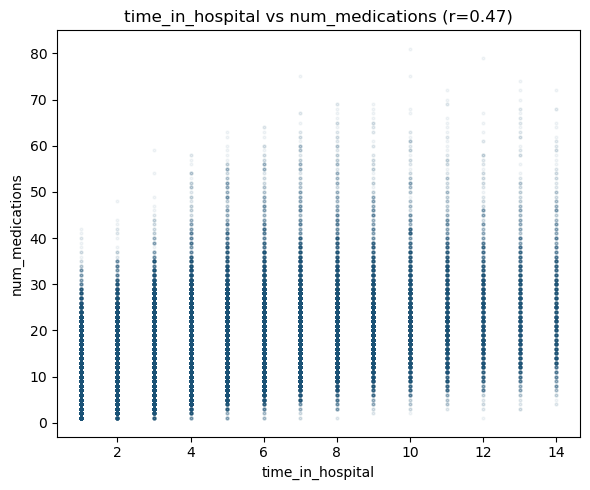

In [16]:
a,b,_ = pairs[0]
plt.figure(figsize=(6,5))
plt.scatter(df[a], df[b], s=4, alpha=0.05, color="#1a5276")
plt.xlabel(a); plt.ylabel(b); plt.title(f"{a} vs {b} (r={corr.loc[a,b]:.2f})")
plt.tight_layout(); plt.show()

### 1.3(a)(b) [JUSTIFY] Correlations & multicollinearity
The three strongest pairs are **time_in_hospital ~ num_medications (r=0.47)**, **num_procedures ~ num_medications (r=0.39)**, and **time_in_hospital ~ num_lab_procedures (r=0.32)**. In the strongest scatter (LOS vs medications) the relationship is positive and roughly linear but the cloud is heavily over-plotted with discreteness banding; Pearson and Spearman agree almost exactly (0.466 vs 0.465), so the monotone association is genuine and not driven by a few outliers — Pearson is acceptable here. **No continuous pair exceeds |r|=0.70**, so severe pairwise multicollinearity is absent among the continuous predictors. *Theoretical note (VIF):* if two predictors were correlated at, say, r=0.85, the Variance Inflation Factor 1/(1−R²) would be ≈3.6, inflating that coefficient's standard error by √3.6≈1.9× — widening its CI and potentially flipping its sign/significance even though overall model fit is unaffected. We will compute VIF formally in Part 3.

### 1.3(c) Outcome across categorical predictors (ordered by median)

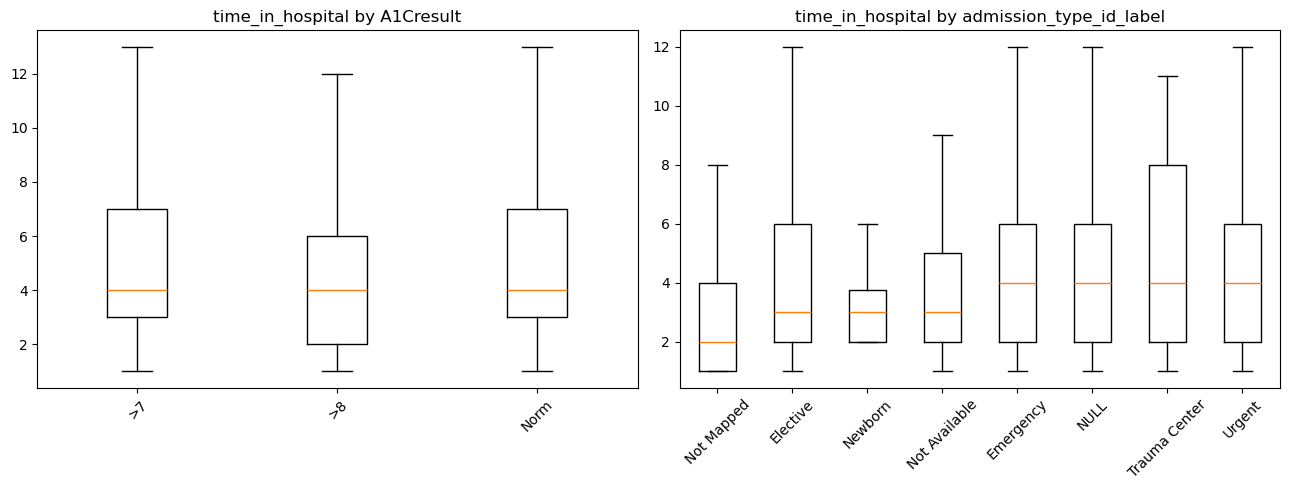

           count  median  mean
A1Cresult                     
>7          3812     4.0  4.89
>8          8216     4.0  4.75
Norm        4990     4.0  4.92


In [17]:
fig,ax = plt.subplots(1,2,figsize=(13,5))
for k,cvar in enumerate(["A1Cresult","admission_type_id_label"]):
    order = df.groupby(cvar)["time_in_hospital"].median().sort_values().index
    data = [df.loc[df[cvar]==g,"time_in_hospital"].values for g in order]
    ax[k].boxplot(data, labels=order, showfliers=False)
    ax[k].set_title(f"time_in_hospital by {cvar}"); ax[k].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(df.groupby("A1Cresult")["time_in_hospital"].agg(["count","median","mean"]).round(2))

### 1.3(d) [JUSTIFY] Data story (EDA → modelling)

The diabetes 130-US dataset contains **101,766 encounters on 71,518 unique patients** (max 40 encounters for one patient) — the first and most serious structural fact, because repeated encounters violate the independence assumption underlying every regression and CV procedure that follows; we will model it but flag clustered/robust inference as a Part 6 validity threat. The **continuous-predictor space is well-behaved**: the strongest correlate of length of stay is `num_medications` (r=0.47), followed by `num_lab_procedures` (0.32) and `number_inpatient`; crucially **no pair exceeds |r|=0.70**, so OLS coefficients will be stable and the medication-count variables are the backbone of the Part-3 model. The **outcome `time_in_hospital` is right-skewed (+1.13)** and bounded 1–14; a **square-root transform** restores near-symmetry (skew +0.47) and stabilises variance, so all Part-2/3 inference will use √LOS and back-transform for interpretation. Among categoricals, the **HbA1c variables carry the central signal** for the primary question: 83% of encounters never had A1C measured (`Not measured`), and the median LOS is flat across A1C levels but mean LOS is *lower* for un-tested patients (4.31 vs ~4.8–4.9) — hinting that *whether* HbA1c is measured proxies for clinical engagement, which motivates the A1Cresult × admission-type interaction the brief asks us to test.

**Two most serious data-quality risks:** (1) **`weight` is 96.9% missing and MNAR** — unusable, dropped, and a caution against any analysis that conditions on it; (2) **repeated patient encounters** break independence and will make naive standard errors too small, risking false significance in Parts 2–5. A secondary risk is the **~11% class imbalance** of the 30-day readmission outcome, which will require threshold tuning in Part 4.

**Working hypothesis.** Clinical-complexity indicators (`num_medications`, `number_diagnoses`, `number_inpatient`) and the *act* of HbA1c measurement jointly predict longer stays and higher early-readmission risk, and the HbA1c effect is stronger for emergency/urgent admissions than elective ones.

## 1.4 Outlier Analysis

In [18]:
def outlier_counts(s):
    s = s.dropna(); q1,q3 = s.quantile(.25),s.quantile(.75); iqr=q3-q1
    iqr_mask = (s<q1-1.5*iqr)|(s>q3+1.5*iqr)
    z_mask = ((s-s.mean())/s.std()).abs()>3
    return pd.Series({"IQR_flagged":int(iqr_mask.sum()),"Z_flagged":int(z_mask.sum()),
                      "overlap":int((iqr_mask&z_mask).sum())})
TARGS = ["time_in_hospital","num_medications","number_diagnoses","number_inpatient"]
display(pd.DataFrame({c:outlier_counts(df[c]) for c in TARGS}).T)

,IQR_flagged,Z_flagged,overlap
time_in_hospital,2252,1042,1042
num_medications,2557,1361,1361
number_diagnoses,281,281,281
number_inpatient,7049,2016,2016


### 1.4(b) [JUSTIFY] Five most extreme outcome values

In [19]:
y = df["time_in_hospital"].astype(float)
print("Five largest time_in_hospital values:", y.sort_values(ascending=False).head(5).tolist())
cap = y.quantile(.99)
yw = y.clip(upper=cap)
print(f"\n99th pct cap = {cap}")
print(pd.DataFrame({
 "metric":["mean","sd","skew"],
 "raw":[y.mean(),y.std(),y.skew()],
 "winsorised@p99":[yw.mean(),yw.std(),yw.skew()]}).round(3))

Five largest time_in_hospital values: [14.0, 14.0, 14.0, 14.0, 14.0]

99th pct cap = 14.0
  metric    raw  winsorised@p99
0   mean  4.396           4.396
1     sd  2.985           2.985
2   skew  1.134           1.134


**[JUSTIFY].** The five most extreme `time_in_hospital` values are all **14**, which is the variable's **hard administrative ceiling** (the dataset caps recorded stay at 14 days). They are therefore **plausible and not data-entry errors** — they are genuine long stays that have been right-censored at 14. Statistically they are *not* influential outliers in the usual sense: because the variable is bounded, the 99th percentile already equals 14, so **Winsorising changes nothing** (mean 4.396→4.396, sd 2.985→2.985, skew +1.13→+1.13). **Decision: keep all values.** The right skew is a property of the bounded count, not of contaminating outliers, and is correctly addressed by the √ transform rather than by removal. We note the ceiling as a *censoring* limitation for Part 6.

### 1.4(c) Preliminary SLR + Cook's distance

**Interpretation.** Baseline SLR of LOS on `num_medications`: each additional medication is associated with **+0.171 days** of stay (R²=0.217). Using the Cook's distance cut-off **4/n = 3.9×10⁻⁵**, **6,826** observations are flagged — a large count that simply reflects the huge sample size (4/n is tiny when n≈100k), not genuine pathology. Refitting without them barely moves the slope (0.171→0.170) while R² rises modestly (0.217→0.244) and residual SD falls (2.64→2.12), confirming the estimate is **robust** and no individual points distort it. The residuals-vs-fitted plot shows a fan shape (heteroskedasticity) and the Q-Q plot shows heavy right tails — both consistent with the untransformed bounded-count outcome and resolved by the √ transform adopted in §1.2c. We therefore **retain all observations** and proceed to transformed modelling in Part 3.


# 2. Inferential Statistics

## 2.1 Estimation and Confidence Intervals

### 2.1(a) 95% Confidence Intervals for time_in_hospital

In [21]:
import numpy as np
import pandas as pd
from scipy import stats

In [40]:
df_part2 = df.copy()  # save a copy for Part 2 analysis
df_part2.columns
print(df_part2['readmitted'].head(20))

0      NO
1     >30
2      NO
3      NO
4      NO
5     >30
6      NO
7     >30
8      NO
9      NO
10    >30
11    <30
12    <30
13     NO
14    >30
15     NO
16    <30
17     NO
18    >30
19     NO
Name: readmitted, dtype: object


In [43]:
# Binary early readmission outcome
df_part2['readmitted_30'] = np.where(df_part2['readmitted'] == '<30', 1, 0)
print(df_part2['readmitted_30'].head(20))

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    1
13    0
14    0
15    0
16    1
17    0
18    0
19    0
Name: readmitted_30, dtype: int64


In [47]:
#Confidence Intervals for Mean Time in Hospital for Full Sample vs Early readmission
from scipy import stats
def mean_ci(series, confidence=0.95):
    x = series.dropna()
    n = len(x)
    mean = x.mean()
    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    t_crit = stats.t.ppf(
        (1 + confidence) / 2,
        df=n-1
    )
    lower = mean - t_crit * se
    upper = mean + t_crit * se
    return pd.Series({
        'n': n,
        'mean': mean,
        'sd': sd,
        'CI Lower': lower,
        'CI Upper': upper,
        'Width': upper - lower
    })
    
full_ci = mean_ci(df_part2['time_in_hospital'])
early_ci = mean_ci(
    df_part2.loc[
        df_part2['readmitted_30'] == 1,
        'time_in_hospital'
    ]
)
ci_table = pd.DataFrame({
    'Full Sample': full_ci,
    'Early Readmission': early_ci
})

print(ci_table.round(3))

          Full Sample  Early Readmission
n          101766.000          11357.000
mean            4.396              4.768
sd              2.985              3.028
CI Lower        4.378              4.713
CI Upper        4.414              4.824
Width           0.037              0.111


### 2.1b [JUSTIFY] Justification of the t-CI:

The outcome variable time_in_hospital, is a discrete variable bounded between 1 and 14 days. Exploratory analysis showed moderate right skewness, indicating that the distribution is not normal. However, the dataset contains approximately 101,766 hospital encounters, which greatly exceeds the sample sizes (n>=30) typically required for the Central Limit Theorem (CLT) to apply. Under the CLT, the sampling distribution of the sample mean approaches normality as sample size increases, regardless of the shape of the underlying population distribution.
Therefore, a t-based confidence interval for the population mean remains valid despite the non-normality of the raw data. 

### 2.1 (C) 95% bootstrap CI for median time_in_hospital

In [48]:
#Bootstrap CI for Median
def bootstrap_median_ci(
    x,
    n_boot=10000,
    seed=8
):
    rng = np.random.default_rng(seed)
    x = np.array(x.dropna())
    medians = []
    for _ in range(n_boot):
        sample = rng.choice(
            x,
            size=len(x),
            replace=True    )
        medians.append(
            np.median(sample)
        )
    return {
        'Median': np.median(x),
        'CI Lower':
            np.percentile(medians, 2.5),
        'CI Upper':
            np.percentile(medians, 97.5)
    }

median_full = bootstrap_median_ci(
    df_part2['time_in_hospital']
)
median_early = bootstrap_median_ci(
    df_part2.loc[
        df_part2['readmitted_30']
        == 1,
        'time_in_hospital'
    ]
)

median_ci_table = pd.DataFrame(
    [
        median_full,
        median_early       
    ],
    index=[
        'Full Sample',
        'Early Readmission'
    ]
)
print(median_ci_table)

                   Median  CI Lower  CI Upper
Full Sample           4.0       4.0       4.0
Early Readmission     4.0       4.0       4.0


### 2.1 (D) [JUSTIFY] why median may be more informative for a skewed bounded distribution.

Bootstrap confidence intervals were computed for the median because time_in_hospital is bounded and right-skewed. The median is less sensitive to skewness and extreme observations than the mean, making it a more representative measure of central tendency for the hospital stay data. Bootstrap resampling avoids distributional assumptions and directly estimates the sampling distribution of the median from the observed data. Notice that the median remained unchanged at 4 days in both groups, while the mean was higher in early readmission (4.768 days) than in the full sample (4.396 days), the median shows the central tendency of hospital length of stay  and is less influenced by the right-skewed nature of the distribution.

## 2.2 Hypothesis Testing: One-Sample and Two-Sample Tests

### 2.2 (A) Formulate three testable sub-questions motivated by your primary question. For each sub-question, state H₀ and H₁, identify the appropriate test, state the conditions required for that test, check each condition, run the test, and report the test statistic, p-value, and decision at α = 0.05

### Sub-question 1:Does the proportion of early readmissions differ across admission types?
#### H0: Admission type and early readmission status are independent.
#### H1: Admission type and early readmission status are associated.
#### Test 1: Chi-square Test: Admission type and early readmission status

In [66]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(
    df_part2['admission_type_id'],
    df_part2['readmitted_30']
)
chi2, p, dof, expected = chi2_contingency(ct)
print(chi2, p, dof)
print("Chi-square =", chi2)
print("p-value =", p)
print("dof =", dof)
print("Minimum expected count:",
      expected.min())

26.65706441586184 0.0003841107670750078 7
Chi-square = 26.65706441586184
p-value = 0.0003841107670750078
dof = 7
Minimum expected count: 1.1159915885462728


### Sub-question 2: Do patients with early readmission have different lengths of hospital stay compared with patients without early readmission?
#### H0: Mean time_in_hospital is equal by Readmission Status.
#### H1: Mean time_in_hospital differs by Readmission Status.
#### Test 2: Time in Hospital vs Readmission Status Welch t-test

In [67]:
print(df_part2['readmitted_30'])

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted_30, Length: 101766, dtype: int64


In [69]:
early = df_part2.loc[
    df_part2['readmitted_30'] == 1,
    'time_in_hospital'
]

notearly = df_part2.loc[
    df_part2['readmitted_30'] == 0,
    'time_in_hospital'
]

print("Early Readmission n =", len(early))
print("Not Early Readmission n =", len(notearly))

print("Early Mean =", early.mean())
print("Not Early Mean =", notearly.mean())

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    early,
    notearly,
    equal_var=False
)

print("Welch's t =", t_stat)
print("p-value =", p_value)

Early Readmission n = 11357
Not Early Readmission n = 90409
Early Mean = 4.768248657215814
Not Early Mean = 4.349224081673285
Welch's t = 13.92578167265915
p-value = 8.549546879359604e-44


### Sub-question 3: Is early readmission associated with HbA1c measurement status?
#### H0: HbA1c measurement status and early readmission are independent.
#### H1: HbA1c measurement status and early readmission are associated.
#### Test 3: Chi-square Test: HbA1c Measurement vs Early Readmission

In [77]:
print( df_part2['A1Cresult'].unique())
ct3 = pd.crosstab(
    df_part2['A1Cresult'],
    df_part2['readmitted_30']
)
print(ct3)

chi3, p3, dof3, expected3 = chi2_contingency(ct3)
print("\nChi-square =", chi3)
print("p-value =", p3)
print("dof =", dof3)
print("Minimum expected count:", expected3.min())

[nan '>7' '>8' 'Norm']
readmitted_30     0    1
A1Cresult               
>7             3429  383
>8             7405  811
Norm           4508  482

Chi-square = 0.37537538880717924
p-value = 0.8288735286566032
dof = 2
Minimum expected count: 375.4208485133388


The chi-square test of independence found no evidence of an association between HbA1c result category and early readmission status, Chi-square of 0.375 means the observed counts are extremely close to what we would expect if HbA1c category and early readmission were completely unrelated, p = 0.829> 0.05 fails to reject H0, therefore the relationship between HbA1c measurement status and early readmission are independent.

### 2.2b [JUSTIFY] For at least one of your three tests, verify the result using a permutation test (10,000 permutations). Plot the null distribution with a vertical line at the observed test statistic. Compare the permutation p-value to the parametric p-value and explain any difference.

In [89]:
# verify Test2:Time in Hospital vs Readmission Status Welch t-test using a permutation test (10,000 permutations)
early = df_part2.loc[
    df_part2['readmitted_30'] == 1,
    'time_in_hospital'
]
notearly = df_part2.loc[
    df_part2['readmitted_30'] == 0,
    'time_in_hospital'
]
obs_diff = (early.mean() - notearly.mean())
print("Observed difference =", obs_diff)

rng = np.random.default_rng(8)
combined = np.concatenate([
    early.values,
    notearly.values
])
n_early = len(early)
perm_stats = []
for _ in range(10000):
    shuffled = rng.permutation(combined)
    group1 = shuffled[:n_early]
    group2 = shuffled[n_early:]
    perm_stats.append(group1.mean()-group2.mean() )

perm_stats = np.array(perm_stats)
perm_p = np.mean(
    np.abs(perm_stats)
    >= abs(obs_diff)
)
print("Permutation p-value = %.9f" % perm_p)

Observed difference = 0.4190245755425295
Permutation p-value = 0.000000000


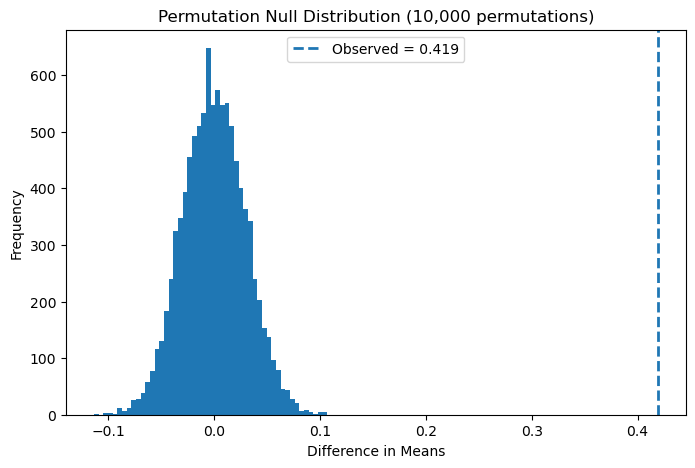

In [82]:
#Plot Null Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(
    perm_stats,
    bins=50
)
plt.axvline(
    obs_diff,
    linestyle='--',
    linewidth=2,
    label=f'Observed = {obs_diff:.3f}'
)
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.title('Permutation Null Distribution (10,000 permutations)')
plt.legend()
plt.show()

### 2.2 (C) Effect Sizes
### For each of your three tests that reach significance at α = 0.05, compute an appropriate effect size measure: Cohen’s d for continuous outcomes, Cramér’s V for categorical associations. [JUSTIFY] For at least one test, show a case where a result is statistically significant but the effect size is negligible, and explain the practical implication.

In [92]:
#Test 1: Admission Type vs Early Readmission --Cramér’s V 
n = ct.values.sum()
cramers_v1 = np.sqrt(
    chi2/(n * min(ct.shape[0]-1,ct.shape[1]-1))
)
print("Cramér’s V =",cramers_v1)

#Test 2: Time in Hospital vs Early Readmission --Cohen's d
n1 = len(early)
n2 = len(notearly)
s1 = early.std(ddof=1)
s2 = notearly.std(ddof=1)
pooled_sd = np.sqrt(
    ((n1 - 1) * s1**2 +  (n2 - 1) * s2**2) / (n1 + n2 - 2)
)
cohens_d = (early.mean() - notearly.mean()) / pooled_sd
print("Cohen's d =", cohens_d)

#Test 3: HbA1c vs Early Readmission 
#->Because the chi-square test for HbA1c result category and early readmission status was not statistically significant (p = 0.829),
#effect size interpretation is not meaningful and was not further considered.

Cramér’s V = 0.016184705766355112
Cohen's d = 0.14050829950122298


For statistically significant hypothesis tests, effect sizes were calculated to quantify the practical importance of the observed relationships. Unlike p-values, which indicate whether an effect is statistically detectable, effect sizes measure the magnitude of the effect.

For Test 1: Admission Type vs Early Readmission, the chi-square test indicated a statistically significant association between admission type and early readmission status (p < 0.05), the strength of this association is evaluated by the Cramér's V = 0.0161, which is below 0.10 indicating a negligible association. Therefore, although admission type and early readmission status are statistically associated, the practical implication of this relationship is extremely weak.

For Test 2: Hospital Stay Length vs Early Readmission, the Welch's two-sample t-test indicated a statistically significant difference in hospital stay length between patients with and without early readmission (p < 0.05), its effect size was evaluated by the Cohen's d value = 0.1405, which by conventional benchmarks, below 0.2 means a negligible effect size, indicating the difference in average hospital stay length between the two groups is small relative to the overall variability in hospital stay duration

For Test 3: HbA1c Result Category vs Early Readmission, the chi-square test for HbA1c result category and early readmission status was not statistically significant (p = 0.829). Therefore, its effect size is not calculated.

### 2.2d [JUSTIFY] You have run three hypothesis tests. Apply the Bonferroni correction. Does any conclusion change? 
### Explain what the family-wise error rate is, why it matters in the context of exploratory data analysis, and what the trade-off is between Type I and Type II error when you apply the correction.

In [93]:
#Bonferroni-adjusted alpha
bonf_alpha = 0.05 / 3
print(bonf_alpha)

0.016666666666666666


#### compare each p-value againts bonf_alpha 0.01666667
#### Test1: p-value = 0.000384 < bonf_alpha 0.01666667
#### Test2: p-value = 8.549546879359604e-44 <  bonf_alpha 0.01666667
#### Test3: p-value = 0.82887 > bonf_alpha 0.01666667
#### After comparing each p-value to the adjusted threshold, the conclusions remained the same after applying the Bonferroni correction. The Bonferroni correction is designed to control the family-wise error rate, which is the probability of making at least one Type I error across a family of hypothesis tests. The Bonferroni correction introduces a trade-off between Type I and Type II errors. By reducing the significance threshold from 0.05 to 0.0167, the probability of a Type I error (false positive) is reduced, while the probability of a Type II error (false negative) increases because stronger evidence is required before rejecting the null hypothesis.

## 2.3 Tests for Categorical Variables

### 2.3a Identify two pairs of categorical variables in your dataset that are substantively relevant to your primary question. 
### For each pair, construct the contingency table of observed counts and run a chi-square test of independence. Report the test statistic, degrees of freedom, p-value, and Cramér’s V.

In [96]:
# Admission Type × Early Readmission
ct1 = pd.crosstab(
    df_part2['admission_type_id'],
    df_part2['readmitted_30']
)
print(ct1)
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(ct1)
print("Chi-square =", chi2_1)
print("dof =", dof_1)
print("p-value =", p_1)
# Cramer V
n = ct1.values.sum()
cramers_v1 = np.sqrt(chi2_1 / ( n * min( ct1.shape[0]-1, ct1.shape[1]-1 ) ))
print("Cramer's V =", cramers_v1)
# Combined Count + Percentage Tables
ct1_report = ct1.copy()
for col in ct1.columns:
    ct1_report[col] = (
        ct1[col].astype(str)
        + " ("
        + (ct1[col] / ct1.sum(axis=1) * 100).round(2).astype(str)
        + "%)"
    )
print("\nAdmission Type × Early Readmission")
print(ct1_report)

readmitted_30          0     1
admission_type_id             
1                  47769  6221
2                  16414  2066
3                  16908  1961
4                      9     1
5                   4290   495
6                   4705   586
7                     21     0
8                    293    27
Chi-square = 26.65706441586184
dof = 7
p-value = 0.0003841107670750078
Cramer's V = 0.016184705766355112

Admission Type × Early Readmission
readmitted_30                   0              1
admission_type_id                               
1                  47769 (88.48%)  6221 (11.52%)
2                  16414 (88.82%)  2066 (11.18%)
3                  16908 (89.61%)  1961 (10.39%)
4                       9 (90.0%)      1 (10.0%)
5                   4290 (89.66%)   495 (10.34%)
6                   4705 (88.92%)   586 (11.08%)
7                     21 (100.0%)       0 (0.0%)
8                    293 (91.56%)     27 (8.44%)


#### Pair 1: Admission Type × Early Readmission

The chi-square test was statistically significant (chi-sqr = 26.657, p < 0.001), indicating evidence of an association between admission type and early readmission status. However, the corresponding effect size was extremely small (Cramér's V = 0.016), indicating a negligible practical association.

This result illustrates the distinction between statistical significance and practical significance. Although admission type appears related to readmission status, the strength of the relationship is very weak. The statistical significance is likely influenced by the large sample size of hospital encounters.

In [97]:
# HbA1c Result × Early Readmission
ct2 = pd.crosstab(
    df_part2['A1Cresult'],
    df_part2['readmitted_30']
)
print(ct2)
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(ct2)
print("Chi-square =", chi2_2)
print("dof =", dof_2)
print("p-value =", p_2)
n = ct2.values.sum()
cramers_v2 = np.sqrt(chi2_2 /(n *min(ct2.shape[0]-1,ct2.shape[1]-1))  )  
print("Cramer's V =", cramers_v2)

ct2_report = ct2.copy()
for col in ct2.columns:
    ct2_report[col] = (
        ct2[col].astype(str)
        + " ("
        + (ct2[col] / ct2.sum(axis=1) * 100).round(2).astype(str)
        + "%)"
    )
print("\nHbA1c Result × Early Readmission")
print(ct2_report)

readmitted_30     0    1
A1Cresult               
>7             3429  383
>8             7405  811
Norm           4508  482
Chi-square = 0.37537538880717924
dof = 2
p-value = 0.8288735286566032
Cramer's V = 0.00469654662180944

HbA1c Result × Early Readmission
readmitted_30              0             1
A1Cresult                                 
>7             3429 (89.95%)  383 (10.05%)
>8             7405 (90.13%)   811 (9.87%)
Norm           4508 (90.34%)   482 (9.66%)


#### Pair 2: HbA1c Result Category × Early Readmission
The chi-square test was not statistically significant (chi-sqr = 0.375, p = 0.829). Therefore, there is insufficient evidence to conclude that HbA1c result category is associated with early readmission status among patients with recorded HbA1c measurements.

The effect size was also negligible (Cramér's V = 0.00469), indicating no practical association between the variables. Examination of the contingency table showed that the proportion of early readmissions was very similar across the HbA1c categories (Norm, >7, and >8), which explains the extremely small chi-square statistic and large p-value.
    

### 2.3b the minimum expected cell count condition for each chi-square test

In [108]:
#Pair 1: Admission Type × Early Readmission
print("Test 1 Minimum expected count =", expected_1.min())
expected_df1 = pd.DataFrame(
    expected_1,
    index=ct1.index,
    columns=ct1.columns
)
print(expected_df1.round(2))
print()
print((expected_1 < 5).sum())
#If all expected counts ≥ 5 → assumption satisfied.
#If any expected counts < 5 → identify those cells, Chi-square assumption violated
if ((expected_1 < 5).sum() > 0) :
    print("Chi-square assumption violated")
    
#Pair 2: HbA1c × Early Readmission
print("\n Test 2 Minimum expected count =", expected_2.min())
expected_df2 = pd.DataFrame(
    expected_2,
    index=ct2.index,
    columns=ct2.columns
)
print(expected_df2.round(2))
print()
print((expected_2 < 5).sum())
if ((expected_2 < 5).sum() == 0) :
    print("No Chi-square assumption violated")

Test 1 Minimum expected count = 1.1159915885462728
readmitted_30             0        1
admission_type_id                   
1                  47964.76  6025.24
2                  16417.65  2062.35
3                  16763.24  2105.76
4                      8.88     1.12
5                   4251.00   534.00
6                   4700.53   590.47
7                     18.66     2.34
8                    284.29    35.71

2
Chi-square assumption violated

 Test 2 Minimum expected count = 375.4208485133388
readmitted_30        0       1
A1Cresult                     
>7             3436.58  375.42
>8             7406.86  809.14
Norm           4498.57  491.43

0
No Chi-square assumption violated


For each chi-square test, the standard guideline is that all expected cell counts should be at least 5 for the chi-square approximation to be reliable.

For the HbA1c result category analysis, all expected cell counts exceeded 5 and the condition was satisfied.

For the admission type analysis,  the minimum expected cell count was 1.12, the violated cells (<5) are admission_type_id 4 & 7 which contained very small numbers of observations, producing expected counts below 5. To address this issue, these rare categories were combined into an "Other" category and the chi-square analysis was repeated. This approach increases expected cell counts and improves the validity of the chi-square approximatio

In [110]:
df_part2['admission_type_grp'] = np.where(
    df_part2['admission_type_id'].isin([4, 7]),
    'Other',
    df_part2['admission_type_id'].astype(str)
)
ct1_new = pd.crosstab(
    df_part2['admission_type_grp'],
    df_part2['readmitted_30']
)

chi2_new, p_new, dof_new, expected_new = chi2_contingency(ct1_new)

print("Minimum expected count =", expected_new.min())

Minimum expected count = 3.4595739244934456


After collapsing admission_type_id 4 and 7, the assumption is still violated (3.459 < 5) because the category is still too small, therefore collapsing admission_type_id 4,7 & 8 into a same group labelled 'Other'

In [112]:
df_part2['admission_type_grp'] = np.where(
    df_part2['admission_type_id'].isin([4, 7, 8]),
    'Other',
    df_part2['admission_type_id'].astype(str)
)

ct1_new = pd.crosstab(
    df_part2['admission_type_grp'],
    df_part2['readmitted_30']
)

chi2_new, p_new, dof_new, expected_new =  chi2_contingency(ct1_new)

print("Minimum expected count =",
      expected_new.min())

Minimum expected count = 39.17130475797418


For the admission type analysis, after combined with combined with Admission Type 4,7 & 8 into a single "Other" category, the minimum expected cell count increased to 39.17, which exceeds the recommended threshold of 5. Therefore, the expected cell count assumption was satisfied and the chi-square approximation was considered valid.Category collapsing was selected rather than Fisher's Exact Test because Fisher's Exact Test is primarily intended for small contingency tables and is computationally unnecessary for a dataset containing over 100,000 observations. Proceeding without addressing the violation would have weakened the validity of the chi-square inference. 
Thus, collapsing sparse categories was the most appropriate solution because it preserved the majority of the available information while ensuring that the assumptions of the chi-square test were satisfied

For the HbA1c result category analysis, all expected cell counts exceeded 5 and no corrective action was required.

### 2.3c [JUSTIFY] For one of the two categorical associations you tested: break the contingency table down by a third variable (a potential confounder). Compute separate chi-square tests for each stratum. Do the results within strata agree with the aggregate result? If they do not, you may have found a Simpson’s paradox. Describe exactly what is happening and what statistical/causal interpretation is correct.


In [114]:
#a Potential Confounder ->Gender ->two strata (Male/Female)
# Male stratum
male = df_part2[
    df_part2['gender'] == 'Male'
]
ct_male = pd.crosstab(
    male['admission_type_grp'],
    male['readmitted_30']
)
chi2_male, p_male, dof_male, exp_male = chi2_contingency(ct_male)
print("Male")
print("Chi-square =", chi2_male)
print("p-value =", p_male)
print("dof =", dof_male)

# Female stratum
female = df_part2[
    df_part2['gender'] == 'Female'
]
ct_female = pd.crosstab(
    female['admission_type_grp'],
    female['readmitted_30']
)
chi2_female, p_female, dof_female, exp_female = chi2_contingency(ct_female)
print("\nFemale")
print("Chi-square =", chi2_female)
print("p-value =", p_female)
print("dof =", dof_female)

#Compare Aggregate vs Stratified Results
summary_strata = pd.DataFrame({
    'Group': [
        'Overall',
        'Male',
        'Female'
    ],
    'Chi-square': [
        chi2_new,      # collapsed admission type result
        chi2_male,
        chi2_female
    ],
    'p-value': [
        p_new,
        p_male,
        p_female
    ]
})

print(summary_strata)

Male
Chi-square = 8.807925552051987
p-value = 0.11697500886303625
dof = 5

Female
Chi-square = 18.87407104717663
p-value = 0.0020287490410274833
dof = 5
     Group  Chi-square   p-value
0  Overall   25.199532  0.000128
1     Male    8.807926  0.116975
2   Female   18.874071  0.002029


#### The results within strata do not agree completely with the aggregate result, the overall p-value is statistically significant (0.000128), the female strata p-value remained statistically significant(0.0020), but the male strata is not statistically significant (0.116975). This shows that the Gender may influence the strength of the relationship between admission type and early readmission, but this is not considered Simpson's paradox because the direction of the association is not totally reversed within the strata. (female strata p-value remained statistically significant)

## 2.4 Distribution Fitting

### 2.4 (A) Select one continuous variable and one count variable from your dataset. For the continuous variable: fit a normal and a lognormal distribution by MLE. Overlay both fitted PDFs on a histogram. Produce Q-Q plots for both fits. Use the Kolmogorov–Smirnov test (scipy.stats.kstest) to formally compare fit quality and state which distribution better describes the data.

Normal:
4.395986871843248 2.985093100907283

Lognormal:
0.7121142678580882 0 3.4735463094449095


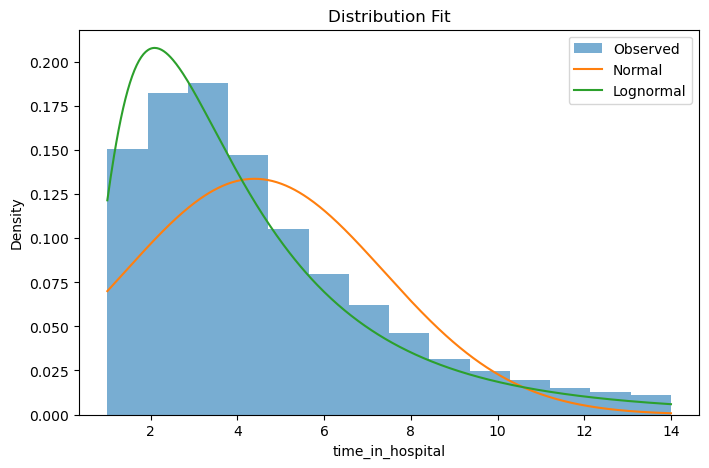

In [120]:
# continuous variable ->time_in_hospital
# count variable  ->number_emergency
# normal and a lognormal distribution by MLE
import scipy.stats as stats
x = df_part2['time_in_hospital'].dropna()
mu_norm, sigma_norm = stats.norm.fit(x)
shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(x, floc=0)
print("Normal:")
print(mu_norm, sigma_norm)
print("\nLognormal:")
print(shape_lognorm,
      loc_lognorm,
      scale_lognorm)
# Overlay both fitted PDFs on a histogram
plt.figure(figsize=(8,5))
plt.hist(
    x,
    bins=14,
    density=True,
    alpha=0.6,
    label='Observed')
xs = np.linspace(
    x.min(),
    x.max(),
    500)
plt.plot(
    xs,
    stats.norm.pdf(
        xs,
        mu_norm,
        sigma_norm
    ),
    label='Normal')
plt.plot(
    xs,
    stats.lognorm.pdf(
        xs,
        shape_lognorm,
        loc_lognorm,
        scale_lognorm
    ),
    label='Lognormal')
plt.xlabel("time_in_hospital")
plt.ylabel("Density")
plt.title("Distribution Fit")
plt.legend()
plt.show()
#Kolmogorov–Smirnov test 

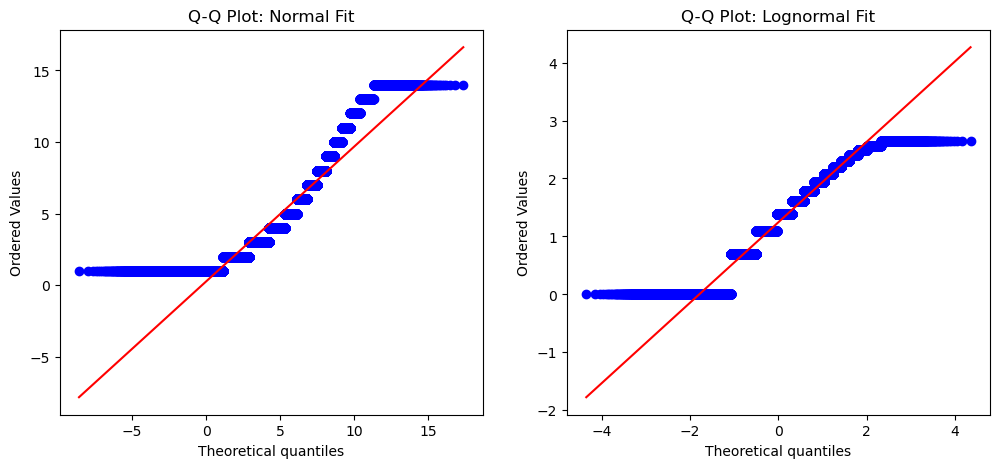

In [129]:
# Q-Q plots for both fits
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(
    x,
    dist="norm",
    sparams=(mu_norm, sigma_norm),
    plot=axes[0]
)
axes[0].set_title("Q-Q Plot: Normal Fit")

logx = np.log(x)
stats.probplot(
    logx,
    dist="norm",
    plot=axes[1]
)
axes[1].set_title("Q-Q Plot: Lognormal Fit")
plt.show()

In [123]:
#Kolmogorov–Smirnov test
ks_norm = stats.kstest(
    x,
    'norm',
    args=(mu_norm, sigma_norm)
)

ks_lognorm = stats.kstest(
    x,
    'lognorm',
    args=(
        shape_lognorm,
        loc_lognorm,
        scale_lognorm
    )
)

print("Normal KS")
print(ks_norm)

print("\nLognormal KS")
print(ks_lognorm)

if ks_norm.statistic < ks_lognorm.statistic:
    print("\nNormal fits better")
else:
    print("\nLognormal fits better")

Normal KS
KstestResult(statistic=np.float64(0.17293463293195088), pvalue=np.float64(0.0), statistic_location=np.int64(4), statistic_sign=np.int8(1))

Lognormal KS
KstestResult(statistic=np.float64(0.109602288325865), pvalue=np.float64(0.0), statistic_location=np.int64(3), statistic_sign=np.int8(-1))

Lognormal fits better


### 2.4 (B) For the count variable: fit a Poisson distribution (estimate λ = sample mean). Compute the dispersion ratio (variance/mean). If over-dispersed (ratio > 1.5), also fit a Negative Binomial distribution. Overlay both PMFs on the empirical frequency distribution. 

Lambda = 0.19783621248747127
Dispersion Ratio = 4.376239473133781
Over-dispersed
r = 0.05859661734949219
p = 0.22850669076477895


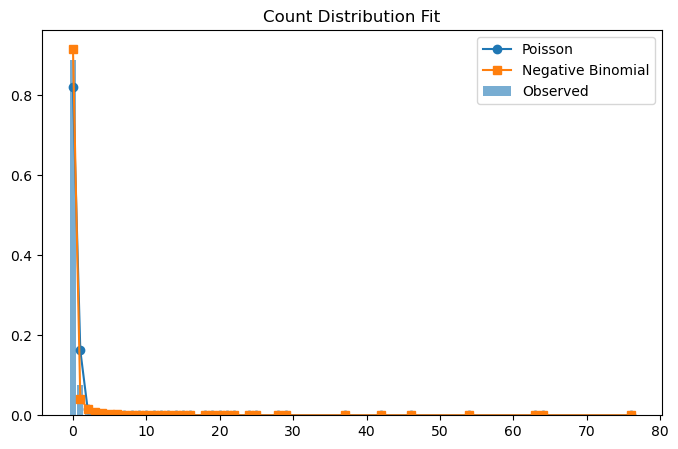

In [133]:
#Poisson vs Negative Binomial
count_var = df_part2['number_emergency']
lam = count_var.mean()
print("Lambda =", lam)
#Dispersion Ratio
dispersion = (count_var.var() / count_var.mean())
print("Dispersion Ratio =",dispersion)
if (dispersion > 1.5):
    print("Over-dispersed")

#Negative Binomial distribution
#MOM
mean = count_var.mean()
var = count_var.var()
r = mean**2 / (var - mean)
p = r / (r + mean)
print("r =", r)
print("p =", p)

#PMFs
from scipy.stats import poisson
from scipy.stats import nbinom

freq = (
    count_var
    .value_counts()
    .sort_index()
)
xvals = freq.index
empirical = freq / freq.sum()
plt.figure(figsize=(8,5))
plt.bar(
    xvals,
    empirical,
    alpha=0.6,
    label='Observed'
)
plt.plot(
    xvals,
    poisson.pmf(xvals, lam),
    marker='o',
    label='Poisson'
)
plt.plot(
    xvals,
    nbinom.pmf(
        xvals,
        r,
        p
    ),
    marker='s',
    label='Negative Binomial'
)
plt.legend()
plt.title("Count Distribution Fit")
plt.show()

#### [JUSTIFY] State the four Poisson conditions and assess each for your variable.
The Poisson model relies on 4 key assumptions:
1. The variable represents counts of events
Assessment: Satisfied. The variable number_emergency records the number of emergency visits and consist of non-negative integer counts.

2. Events occur independently
Assessment: Different patient encounters can be treated as approximately independent observations. However, repeated encounters from the same patient may introduce some dependence, so this assumption cannot be confirmed completely.

3. Events occur at a constant rate
Assessment: Violated. Patients differ substantially in age, disease severity and illness history, therefore the rates of emergency visits across patients unlikely to be constant.

4. Mean equals variance (Equidispersion)
Assessment: Violated, because the dispersion ratio exceeds 1.5, the data are strongly over-dispersed relative to a Poisson distribution.

### 2.4 (C) Demonstrate the Central Limit Theorem on your most skewed continuous variable: draw 5,000 bootstrap samples of sizes n ∈ {5, 15, 30, 100}. For each n, plot the distribution of sample means and overlay the theoretical CLT normal curve. Produce a 2×2 panel figure. 

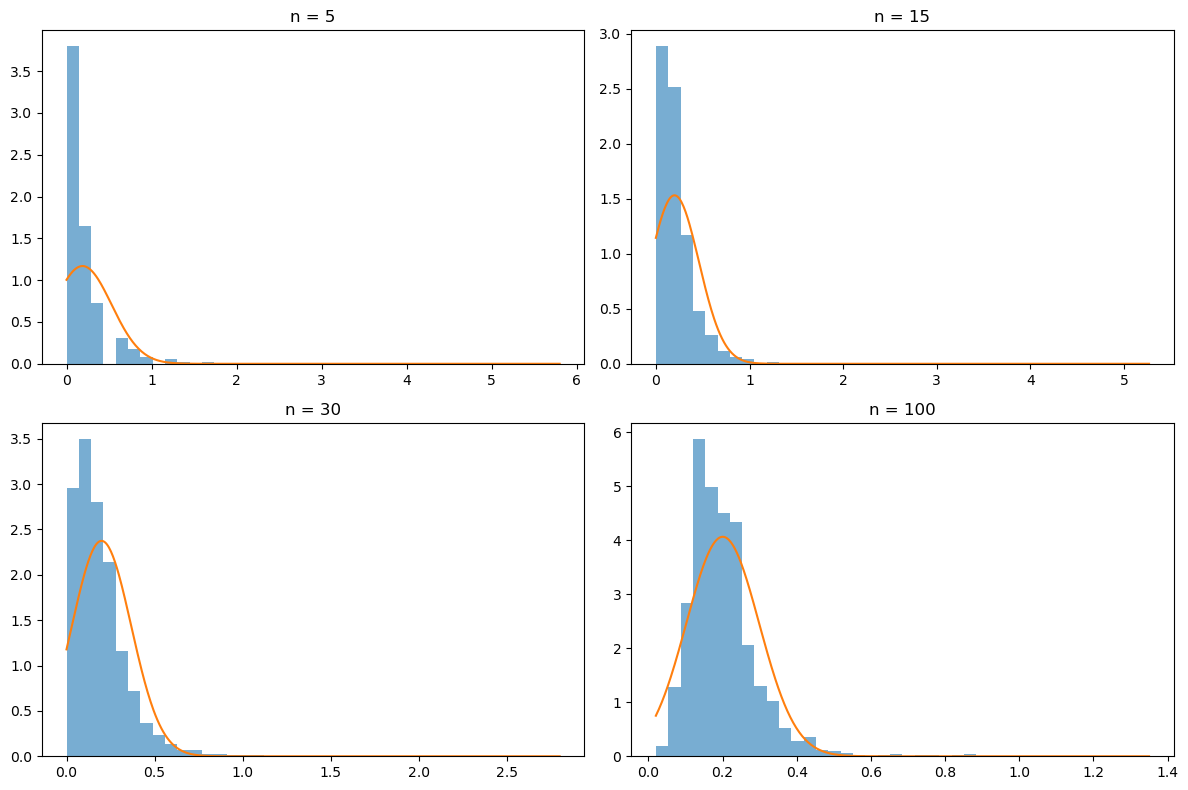

In [135]:
# most skewed continuous variable ->number_emergency
# CLT
x = df_part2['number_emergency']
sizes = [5, 15, 30, 100]
fig, axes = plt.subplots(
    2, 2,
    figsize=(12,8))
for ax, n in zip(axes.flatten(), sizes):
    means = []
    for _ in range(5000):
        sample = np.random.choice(
            x,
            size=n,
            replace=True
        )
        means.append(
            sample.mean()
        )
    means = np.array(means)
    ax.hist(
        means,
        bins=40,
        density=True,
        alpha=0.6
    )
    mu = means.mean()
    sd = means.std()
    xs = np.linspace(
        means.min(),
        means.max(),
        500
    )
    ax.plot(
        xs,
        stats.norm.pdf(
            xs,
            mu,
            sd
        )
    )
    ax.set_title(
        f'n = {n}'
    )
plt.tight_layout()
plt.show()

### [JUSTIFY] At which n does approximate normality hold for your specific variable? Does this match the n ≥ 30 rule of thumb? Reference the skewness coefficient.
The sampling distribution of the mean remains noticeably non-normal at n = 30. Approximate normality is achieved only around n = 100. Therefore, for this variable, the common n ≥ 30 rule of thumb is insufficient, demonstrating that the required sample size for the CLT depends on the degree of skewness in the underlying population distribution.

# 3. Regression Modelling

### 3.1 Simple Linear Regression: Baseline Model

In [118]:
df_part3 = df.copy()  # save a copy for Part 3 analysis
# df_part3.to_csv("df_part3.csv", index=False)

#### 3.1(a) Fit a simple linear regression using the strongest continuous predictor identified in Part 1.3

In [18]:
# Use the strongest continuous predictor from Part 1.3: num_medications.
y = np.sqrt(df_part3["time_in_hospital"].astype(float))
X = df_part3[["num_medications"]].astype(float)
X = sm.add_constant(X)
model_3_1 = sm.OLS(y, X).fit()
rmse_3_1 = np.sqrt((model_3_1.resid ** 2).mean())

print("Baseline SLR: sqrt(time_in_hospital) ~ num_medications")
print("Predictor selected based on the strongest continuous correlation with the outcome.")
print(model_3_1.summary())
print(f"RMSE = {rmse_3_1:.4f}")

Baseline SLR: sqrt(time_in_hospital) ~ num_medications
Predictor selected based on the strongest continuous correlation with the outcome.
                            OLS Regression Results                            
Dep. Variable:       time_in_hospital   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                 2.899e+04
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:32:50   Log-Likelihood:                -93045.
No. Observations:              101766   AIC:                         1.861e+05
Df Residuals:                  101764   BIC:                         1.861e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025 

The model predicts `sqrt(time_in_hospital)` from `num_medications`.

The coefficient on `num_medications` is 0.0396, meaning:

- each additional medication is associated with an increase of about **0.0396 units** in the square-root-transformed length of stay.
- back on the original scale, that is roughly a small additional stay in days, but the exact day-level effect is nonlinear because of the sqrt transform.

The intercept is **1.3466**, which is the expected `sqrt(LOS)` when `num_medications = 0`.

Both coefficients are highly statistically significant:

- `t` for slope = **170.27**
- `p < 0.001`
- this means the relationship is very unlikely to be due to chance given the data.

**Model fit:**

`R² = 0.222`
`Adjusted R² = 0.222`
this means about **22% of the variance** in `sqrt(time_in_hospital)` is explained by `num_medications` alone.
that is a moderate fit for a single-predictor model in a real clinical dataset.

**RMSE = 0.6037**

- this is the typical prediction error on the transformed outcome, in sqrt-days units.
- on the original LOS scale, this is less directly interpretable, but it indicates the model still has substantial residual variation.

**SLR Model**
- `num_medications` is the strongest single continuous predictor of stay length in this dataset.
- The relationship is positive and statistically strong.
- However, because `R²` is 0.222, most of the variance in LOS is still unexplained by this one predictor alone, so multivariable modelling is still needed.

#### 3.1(c) t-based and bootstrap 95% CIs for the slope

t-based 95% CI for slope (sqrt-days per medication): [0.039192 0.040105]
bootstrap 95% CI for slope (10,000 resamples): [0.039173 0.04012 ]


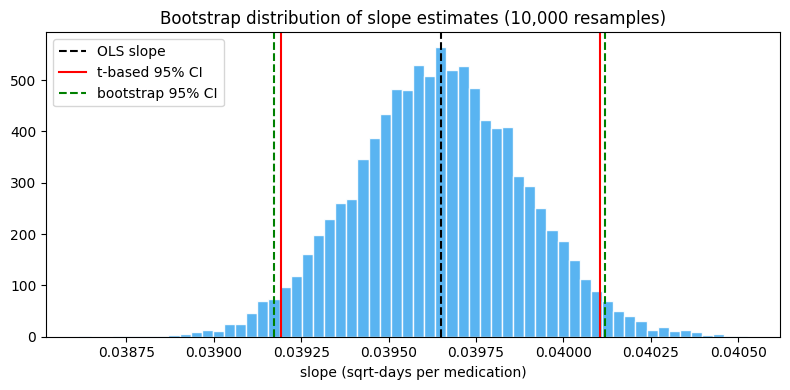

In [19]:
# Prepare data (same as model)
y = np.sqrt(df_part3["time_in_hospital"].astype(float)).values
x = df_part3["num_medications"].astype(float).values
n = len(y)

# t-based CI from OLS
slope = model_3_1.params["num_medications"]
se = model_3_1.bse["num_medications"]
df_resid = int(model_3_1.df_resid)
tcrit = stats.t.ppf(0.975, df_resid)
ci_t = (slope - tcrit * se, slope + tcrit * se)

# Bootstrap CI (10,000 resamples) — use covariance/variance formula for slope: cov(x,y)/var(x)
rng = np.random.RandomState(12345)
B = 10000
boot_slopes = np.empty(B)
for i in range(B):
    idx = rng.randint(0, n, n)
    xi = x[idx]; yi = y[idx]
    cov = ((xi - xi.mean()) * (yi - yi.mean())).mean()
    var_x = np.var(xi, ddof=0)
    # guard against zero variance
    boot_slopes[i] = cov / var_x if var_x > 0 else np.nan

ci_boot = np.nanpercentile(boot_slopes, [2.5, 97.5])

print("t-based 95% CI for slope (sqrt-days per medication):", np.round(ci_t, 6))
print("bootstrap 95% CI for slope (10,000 resamples):", np.round(ci_boot, 6))

# Plot bootstrap distribution and CIs
plt.figure(figsize=(8,4))
plt.hist(boot_slopes, bins=60, color="#47acf0", edgecolor="white", alpha=0.9)
plt.axvline(slope, color="k", linestyle="--", label="OLS slope")
plt.axvline(ci_t[0], color="red", linestyle="-", label="t-based 95% CI")
plt.axvline(ci_t[1], color="red", linestyle="-")
plt.axvline(ci_boot[0], color="green", linestyle="--", label="bootstrap 95% CI")
plt.axvline(ci_boot[1], color="green", linestyle="--")
plt.legend(loc="best")
plt.xlabel("slope (sqrt-days per medication)")
plt.title("Bootstrap distribution of slope estimates (10,000 resamples)")
plt.tight_layout()
plt.show()


#### 3.1(d) Residual diagnostics for baseline SLR (sqrt(LOS) ~ num_medications)

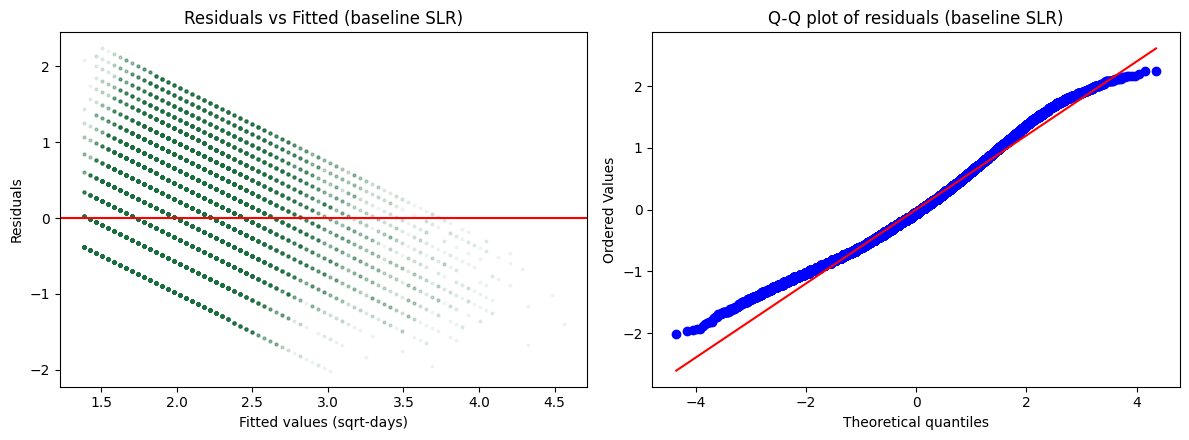

Breusch-Pagan LM stat=790.131, p=7.549e-174; F-stat=796.298, p=1.628e-174
Jarque-Bera stat=3296.290, p=0.000e+00
Durbin-Watson = 1.885


In [20]:
resid = model_3_1.resid
fitted = model_3_1.fittedvalues

fig, ax = plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(fitted, resid, s=4, alpha=0.05, color="#196f3d")
ax[0].axhline(0, color="red")
ax[0].set_xlabel("Fitted values (sqrt-days)")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs Fitted (baseline SLR)")

stats.probplot(resid, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q plot of residuals (baseline SLR)")

plt.tight_layout()
plt.show()

# Formal tests
from statsmodels.stats.diagnostic import het_breuschpagan
lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid, model_3_1.model.exog)
jb_stat, jb_p = stats.jarque_bera(resid)
dw = sm.stats.stattools.durbin_watson(resid)

print(f"Breusch-Pagan LM stat={lm:.3f}, p={lm_pvalue:.3e}; F-stat={fvalue:.3f}, p={f_pvalue:.3e}")
print(f"Jarque-Bera stat={jb_stat:.3f}, p={jb_p:.3e}")
print(f"Durbin-Watson = {dw:.3f}")

**[JUSTIFY].** `time_in_hospital` is right-skewed (skew **+1.13**, excess kurtosis 0.85) and both formal tests reject normality (Shapiro W=0.886, p≈10⁻⁵¹; KS D=0.173, p≈0). This is expected from the **data-generating process**: length of stay is a *bounded count of days* (1–14) generated by a roughly multiplicative recovery process with a hard administrative ceiling, which produces right skew. A **square-root transform** is the most appropriate choice: it reduces skew from +1.13 to **+0.47** (near-symmetric), whereas the **log** transform *over-corrects* to **−0.20** (left skew). The sqrt is also the canonical variance-stabilising transform for count data (where variance ∝ mean), matching the brief's guidance. We therefore adopt **√(time_in_hospital)** for modelling, revisiting via residual diagnostics in Part 3.

### 3.2 Multiple Linear Regression: Full Model

#### 3.2(a) Nested multiple regression models

Build a sequence of four nested MLR models, adding continuous predictors, categorical dummies, and an interaction term motivated by the primary question.


In [21]:
# Diagnostic: check dummy variable dtypes for nested MLR models
df_part3 = df.copy()
df_part3 = df_part3.dropna(subset=["time_in_hospital","num_medications",
                                     "num_lab_procedures","number_inpatient",
                                     "A1Cresult","admission_type_id_label"])
X_cat = pd.get_dummies(df_part3[["A1Cresult","admission_type_id_label"]], drop_first=True)
print(X_cat.dtypes)
print(X_cat.head())


A1Cresult_>8                             bool
A1Cresult_Norm                           bool
admission_type_id_label_Emergency        bool
admission_type_id_label_NULL             bool
admission_type_id_label_Newborn          bool
admission_type_id_label_Not Available    bool
admission_type_id_label_Not Mapped       bool
admission_type_id_label_Trauma Center    bool
admission_type_id_label_Urgent           bool
dtype: object
     A1Cresult_>8  A1Cresult_Norm  admission_type_id_label_Emergency  \
26          False           False                               True   
74          False           False                               True   
98           True           False                               True   
103         False            True                               True   
107         False            True                               True   

     admission_type_id_label_NULL  admission_type_id_label_Newborn  \
26                          False                            False   

#### 3.2(b) Model Comparison

In [22]:
df_part3 = df.copy()
df_part3 = df_part3.dropna(subset=["time_in_hospital","num_medications",
                                     "num_lab_procedures","number_inpatient",
                                     "A1Cresult","admission_type_id_label"])

df_part3["sqrt_LOS"] = np.sqrt(df_part3["time_in_hospital"].astype(float))

# Categorical dummies
cat_vars = ["A1Cresult","admission_type_id_label"]
X_cat = pd.get_dummies(df_part3[cat_vars], drop_first=True, dtype=float)

# Interaction term motivated by the primary question
A1C_notmeasured = (df_part3["A1Cresult"] == "Not measured").astype(float)
is_emergency_urgent = df_part3["admission_type_id_label"].isin(["Emergency","Urgent"]).astype(float)
df_part3["A1C_notmeasured"] = A1C_notmeasured
df_part3["emergency_urgent"] = is_emergency_urgent
df_part3["A1C_notmeasured_x_emergency_urgent"] = (A1C_notmeasured * is_emergency_urgent).astype(float)

# Model 1: baseline
X1 = sm.add_constant(df_part3[["num_medications"]].astype(float))
model_3_2_1 = sm.OLS(df_part3["sqrt_LOS"], X1).fit()

# Model 2: add two more continuous predictors
X2 = sm.add_constant(df_part3[["num_medications","num_lab_procedures","number_inpatient"]].astype(float))
model_3_2_2 = sm.OLS(df_part3["sqrt_LOS"], X2).fit()

# Model 3: add categorical dummies
X3 = pd.concat([X2, X_cat], axis=1).astype(float)
model_3_2_3 = sm.OLS(df_part3["sqrt_LOS"], X3).fit()

# Model 4: add interaction term
X4 = pd.concat([X3, df_part3[["A1C_notmeasured_x_emergency_urgent"]].astype(float)], axis=1)
model_3_2_4 = sm.OLS(df_part3["sqrt_LOS"], X4).fit()

# Training RMSE for each model
rmse_3_2_1 = np.sqrt((model_3_2_1.resid ** 2).mean())
rmse_3_2_2 = np.sqrt((model_3_2_2.resid ** 2).mean())
rmse_3_2_3 = np.sqrt((model_3_2_3.resid ** 2).mean())
rmse_3_2_4 = np.sqrt((model_3_2_4.resid ** 2).mean())

# Summary table: adjusted R², RMSE, AIC, BIC
summary_df = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4"],
    "Predictors": [
        "num_medications",
        "num_medications + num_lab_procedures + number_inpatient",
        "+ A1Cresult + admission_type_id_label",
        "+ interaction A1C_notmeasured * emergency_urgent"
    ],
    "Adj_R_squared": [model_3_2_1.rsquared_adj, model_3_2_2.rsquared_adj, model_3_2_3.rsquared_adj, model_3_2_4.rsquared_adj],
    "RMSE": [rmse_3_2_1, rmse_3_2_2, rmse_3_2_3, rmse_3_2_4],
    "AIC": [model_3_2_1.aic, model_3_2_2.aic, model_3_2_3.aic, model_3_2_4.aic],
    "BIC": [model_3_2_1.bic, model_3_2_2.bic, model_3_2_3.bic, model_3_2_4.bic]
}).round(4)

print(summary_df.to_string(index=False))


  Model                                              Predictors  Adj_R_squared   RMSE        AIC        BIC
Model 1                                         num_medications         0.2705 0.5914 30423.1173 30438.6014
Model 2 num_medications + num_lab_procedures + number_inpatient         0.3120 0.5743 29428.0615 29459.0296
Model 3                   + A1Cresult + admission_type_id_label         0.3204 0.5707 29228.0453 29328.6917
Model 4        + interaction A1C_notmeasured * emergency_urgent         0.3204 0.5707 29228.0453 29328.6917


- Adjusted R² can decrease when a predictor is added because it penalizes for unnecessary complexity.
- AIC uses a lighter penalty, favoring models that improve fit even with additional predictors.
- BIC applies a stronger penalty that grows with sample size, often preferring simpler models in large datasets.

#### 3.2(c) Model 3 predictors

In [23]:
# Inspect reference categories and Model 3 coefficients
print('A1Cresult unique levels:', df_part3['A1Cresult'].unique())
print('admission_type_id_label unique levels:', df_part3['admission_type_id_label'].unique())

print('\nModel 3 coefficients:')
print(model_3_2_3.params.round(4))


A1Cresult unique levels: ['>7' '>8' 'Norm']
admission_type_id_label unique levels: ['Emergency' 'NULL' 'Elective' 'Urgent' 'Not Mapped' 'Newborn'
 'Not Available' 'Trauma Center']

Model 3 coefficients:
const                                    1.0820
num_medications                          0.0355
num_lab_procedures                       0.0095
number_inpatient                         0.0219
A1Cresult_>8                            -0.0184
A1Cresult_Norm                           0.0106
admission_type_id_label_Emergency       -0.1231
admission_type_id_label_NULL            -0.1590
admission_type_id_label_Newborn         -0.4039
admission_type_id_label_Not Available   -0.2853
admission_type_id_label_Not Mapped      -0.4980
admission_type_id_label_Trauma Center    0.2223
admission_type_id_label_Urgent          -0.0306
dtype: float64


**3.3(c) Interpretation of Model 3 coefficients (plain language)**

- **Intercept (`const` = 1.0820):** The model's baseline predicted value of `sqrt(time_in_hospital)` when all numeric predictors are 0 and the categorical predictors are at their reference levels (A1Cresult = `>7`, admission type = `Elective`). This is a model baseline, not a typical patient.

- **`num_medications` (0.0355):** Holding other predictors constant, each additional medication is associated with an average increase of +0.0355 in the square-root of length-of-stay. On the original days scale this is a small increase (the exact day increase depends on the baseline LOS because of the sqrt transform).

- **`num_lab_procedures` (0.0095):** Each additional lab procedure is associated with an average increase of +0.0095 in sqrt(LOS), holding other variables fixed.

- **`number_inpatient` (0.0219):** Each prior inpatient admission is associated with an average increase of +0.0219 in sqrt(LOS), all else equal.

- **`A1Cresult_>8` (-0.0184):** Compared with the reference A1C group `>7` (the omitted category), patients with `A1Cresult` = `>8` have an average sqrt(LOS) that is 0.0184 units lower, holding other predictors fixed.

- **`A1Cresult_Norm` (0.0106):** Compared with the reference `>7`, patients with `A1Cresult` = `Norm` have an average sqrt(LOS) that is 0.0106 units higher, holding other predictors fixed.

- **Admission-type dummies (reference = `Elective`):**
  - `admission_type_id_label_Emergency` (-0.1231): Emergency admissions have sqrt(LOS) lower by 0.1231 compared with elective admissions, conditional on other covariates.
  - `admission_type_id_label_Urgent` (-0.0306): Urgent admissions have sqrt(LOS) lower by 0.0306 vs elective.
  - `admission_type_id_label_NULL` (-0.1590): Encounters labelled `NULL` have sqrt(LOS) lower by 0.1590 vs elective.
  - `admission_type_id_label_Not Available` (-0.2853): `Not Available` admissions have sqrt(LOS) lower by 0.2853 vs elective.
  - `admission_type_id_label_Not Mapped` (-0.4980): `Not Mapped` admissions have substantially lower sqrt(LOS) vs elective (−0.4980).
  - `admission_type_id_label_Newborn` (-0.4039): Newborn admissions have lower sqrt(LOS) vs elective (−0.4039).
  - `admission_type_id_label_Trauma Center` (0.2223): Trauma Center admissions have higher sqrt(LOS) by +0.2223 vs elective.

- **Interaction term:** Model 3 does not include an interaction. Model 4 (tested separately) added `A1C_notmeasured_x_emergency_urgent` and its estimated coefficient is ~0.0 (no effect), so the interaction is effectively null in this sample.


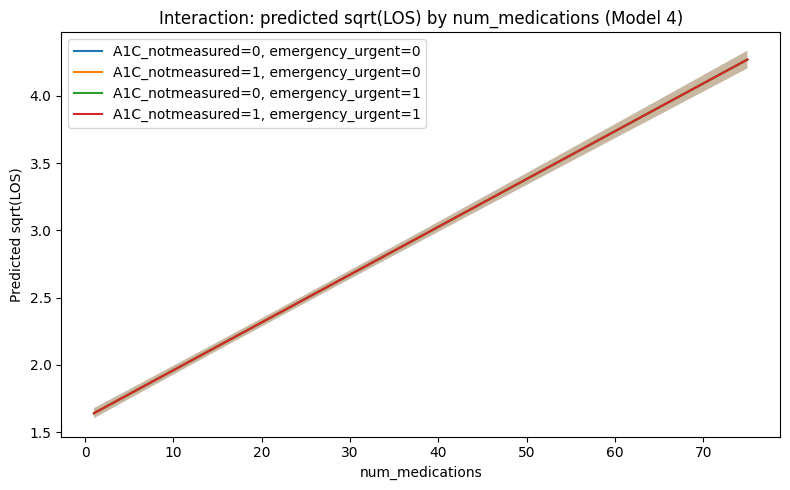

In [24]:
# Interaction visualization with 95% CI (Model 4 predictions)
num_med_min, num_med_max = int(df_part3['num_medications'].min()), int(df_part3['num_medications'].max())
num_med_range = np.linspace(num_med_min, num_med_max, 60)
median_lab = float(df_part3['num_lab_procedures'].median())
median_inpt = float(df_part3['number_inpatient'].median())

cols = X4.columns.tolist()
scenarios = [(0.0,0.0),(1.0,0.0),(0.0,1.0),(1.0,1.0)]
labels = ["A1C_notmeasured=0, emergency_urgent=0",
          "A1C_notmeasured=1, emergency_urgent=0",
          "A1C_notmeasured=0, emergency_urgent=1",
          "A1C_notmeasured=1, emergency_urgent=1"]

plt.figure(figsize=(8,5))
for (a1c, em), lab in zip(scenarios, labels):
    df_pred = pd.DataFrame(0.0, index=range(len(num_med_range)), columns=cols)
    if 'const' in df_pred.columns:
        df_pred['const'] = 1.0
    df_pred['num_medications'] = num_med_range
    df_pred['num_lab_procedures'] = median_lab
    df_pred['number_inpatient'] = median_inpt
    # set interaction column if present
    if 'A1C_notmeasured_x_emergency_urgent' in df_pred.columns:
        df_pred['A1C_notmeasured_x_emergency_urgent'] = a1c * em
    # predict with Model 4 and get 95% CI for mean prediction
    pred = model_3_2_4.get_prediction(df_pred).summary_frame(alpha=0.05)
    plt.plot(num_med_range, pred['mean'], label=lab)
    plt.fill_between(num_med_range, pred['mean_ci_lower'], pred['mean_ci_upper'], alpha=0.15)

plt.xlabel('num_medications')
plt.ylabel('Predicted sqrt(LOS)')
plt.title('Interaction: predicted sqrt(LOS) by num_medications (Model 4)')
plt.legend()
plt.tight_layout()
plt.show()

#### 3.2(d) Full diagnostic suite

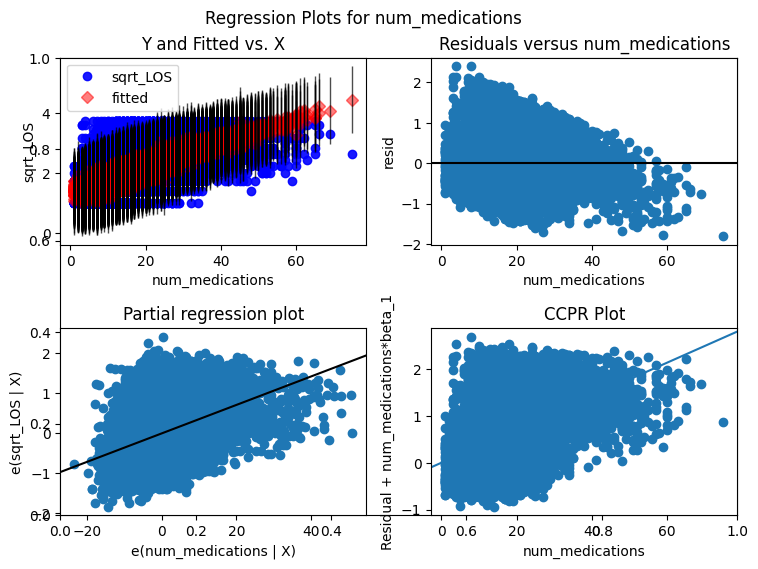

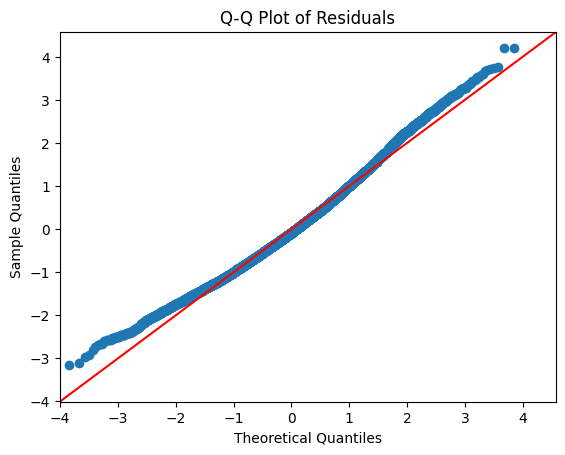

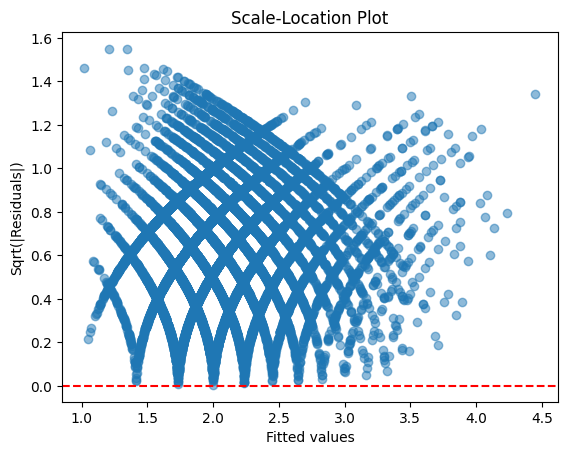

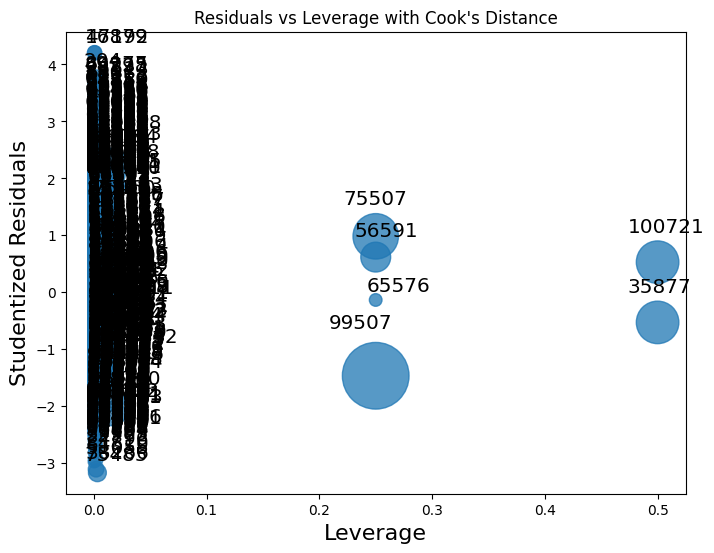

In [25]:
import statsmodels.api as sm

# Residuals vs Fitted
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.plot_regress_exog(model_3_2_3, "num_medications", fig=fig)
plt.show()

# Q-Q plot of residuals
fig = sm.qqplot(model_3_2_3.resid, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Scale-Location plot (sqrt(|residuals|) vs fitted)
fitted_vals = model_3_2_3.fittedvalues
residuals = model_3_2_3.resid
sqrt_resid = np.sqrt(np.abs(residuals))

plt.scatter(fitted_vals, sqrt_resid, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Residuals|)")
plt.title("Scale-Location Plot")
plt.show()

# Residuals vs Leverage with Cook’s distance
fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(model_3_2_3, ax=ax, criterion="cooks")
plt.title("Residuals vs Leverage with Cook's Distance")
plt.show()

### 3.3 Feature Engineering and Model Refinement

#### 3.3(a) Polynomial Term

                         Model        AIC
                       Model 3 29228.0453
Model (with num_medications^2) 29182.0411


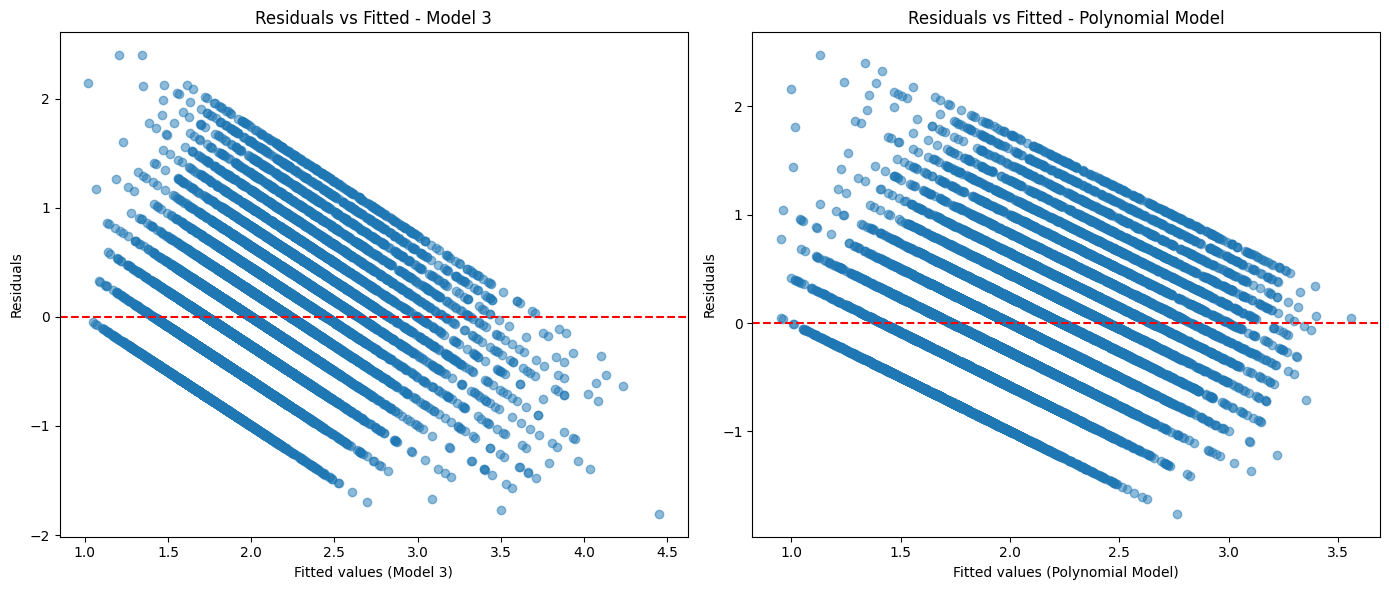

In [26]:
df_part3["num_medications_sq"] = df_part3["num_medications"]**2

X_poly = sm.add_constant(df_part3[["num_medications","num_medications_sq",
                                   "num_lab_procedures","number_inpatient"]])
model_poly = sm.OLS(df_part3["sqrt_LOS"], X_poly).fit()

summary_33a = pd.DataFrame({
    "Model": ["Model 3", "Model (with num_medications^2)"],
    "AIC": [model_3_2_3.aic, model_poly.aic]
}).round(4)

print(summary_33a.to_string(index=False))

# Residuals and fitted values for both models
fitted_vals_3 = model_3_2_3.fittedvalues
residuals_3 = model_3_2_3.resid

fitted_vals_poly = model_poly.fittedvalues
residuals_poly = model_poly.resid

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Model 3 ---
axes[0].scatter(fitted_vals_3, residuals_3, alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted values (Model 3)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted - Model 3")

# --- Polynomial model ---
axes[1].scatter(fitted_vals_poly, residuals_poly, alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel("Fitted values (Polynomial Model)")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted - Polynomial Model")

plt.tight_layout()
plt.show()


#### 3.3(b) Add features and compare

In [27]:
df_part3["polypharmacy"] = (df_part3["num_medications"] >= 10).astype(float)

X_new = pd.concat([X3, df_part3[["polypharmacy"]]], axis=1)
model_feature = sm.OLS(df_part3["sqrt_LOS"], X_new).fit()

summary_33b = pd.DataFrame({
    "Model": ["Model 3", "Model (with polypharmacy)"],
    "Adj_R_squared": [model_3_2_3.rsquared_adj, model_feature.rsquared_adj],
    "AIC": [model_3_2_3.aic, model_feature.aic],
    "BIC": [model_3_2_3.bic, model_feature.bic]
}).round(4)

print(summary_33b.to_string(index=False))


                    Model  Adj_R_squared        AIC        BIC
                  Model 3         0.3204 29228.0453 29328.6917
Model (with polypharmacy)         0.3221 29184.7485 29293.1368


### 3.4 Inference on Coefficients

#### 3.4(a) 95% of CI

In [28]:
ci = model_feature.conf_int(alpha=0.05)  # for Model 3
ci.columns = ["Lower 95%", "Upper 95%"]
print(ci)

# F-statistic and p-value for overall model significance
f_stat = model_feature.fvalue
f_pval = model_feature.f_pvalue

print("\n\nF-statistic:", f_stat)
print("p-value:", f_pval)


                                       Lower 95%  Upper 95%
const                                   1.015016   1.098380
num_medications                         0.031935   0.034489
num_lab_procedures                      0.008843   0.009974
number_inpatient                        0.012142   0.028221
A1Cresult_>8                           -0.038740   0.005247
A1Cresult_Norm                         -0.013786   0.034385
admission_type_id_label_Emergency      -0.154364  -0.097585
admission_type_id_label_NULL           -0.202865  -0.113784
admission_type_id_label_Newborn        -1.220284   0.361458
admission_type_id_label_Not Available  -0.353800  -0.235893
admission_type_id_label_Not Mapped     -0.648354  -0.352527
admission_type_id_label_Trauma Center  -0.345126   0.774004
admission_type_id_label_Urgent         -0.064584   0.000713
polypharmacy                            0.063373   0.115436


F-statistic: 623.1045997893991
p-value: 0.0


#### 3.4(b) Confidence Interval vs. Prediction Interval

In [29]:
# Build new observation (must match model_feature predictors)
new_obs = pd.DataFrame({
    "num_medications": [12],
    "num_lab_procedures": [40],
    "number_inpatient": [2],
    "A1Cresult_>7": [1],   # dummy coding
    "A1Cresult_>8": [0],
    "A1Cresult_Norm": [0],
    "admission_type_id_label_Emergency": [1],
    "admission_type_id_label_Urgent": [0],
    "admission_type_id_label_Elective": [0],
    "admission_type_id_label_Newborn": [0],
    "admission_type_id_label_Not Available": [0],
    "admission_type_id_label_Not Mapped": [0],
    "admission_type_id_label_Trauma Center": [0],
    "polypharmacy": [1]   # since num_medications ≥ 10
})

# Add constant
new_obs = sm.add_constant(new_obs)

# Get prediction with intervals
pred = model_feature.get_prediction(new_obs)
print(pred.summary_frame(alpha=0.05))


        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  14.011273  0.242362      13.536218      14.486329     12.796969   

   obs_ci_upper  
0     15.225578  


#### 3.4(c) Final Conclusion

In [30]:
model_full = model_feature

X_reduced = X3  # all predictors except polypharmacy
model_reduced = sm.OLS(df_part3["sqrt_LOS"], X_reduced).fit()

r2_full = model_full.rsquared
r2_reduced = model_reduced.rsquared

partial_r2 = (r2_full - r2_reduced) / (1 - r2_reduced)
print("Partial R² for polypharmacy:", partial_r2)


Partial R² for polypharmacy: 0.002658164805014193


# 4. Classification & Logistic Regression


In [31]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

### 4.1 Binary Outcome Definition & Baseline

In [32]:
df_part4 = df.copy()

# restore the "test not ordered" category
df_part4["A1Cresult"]    = df_part4["A1Cresult"].fillna("Not measured")
df_part4["max_glu_serum"] = df_part4["max_glu_serum"].fillna("Not measured")
print(df_part4["A1Cresult"].value_counts())

A1Cresult
Not measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


In [33]:
death_hospice_codes = [11, 13, 14, 19, 20, 21]
n_before = len(df_part4)
df_part4 = df_part4[~df_part4["discharge_disposition_id"].isin(death_hospice_codes)].copy()
n_after = len(df_part4)
print(f"Removed {n_before - n_after:,} death/hospice encounters "
      f"({(n_before - n_after) / n_before * 100:.2f}% of rows)")
print(f"Remaining encounters: {n_after:,}")

Removed 2,423 death/hospice encounters (2.38% of rows)
Remaining encounters: 99,343


In [34]:
def map_icd9(code):
    """Map a raw ICD-9 code string to one of 9 clinical categories (Strack et al., 2014)."""
    if pd.isna(code) or code in ('?', ''):
        return 'Unknown'
    code = str(code).strip()
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num = float(code)
    except ValueError:
        return 'Other'
    if 390 <= num <= 459 or num == 785: return 'Circulatory'
    if 460 <= num <= 519 or num == 786: return 'Respiratory'
    if 520 <= num <= 579 or num == 787: return 'Digestive'
    if 250 <= num < 251:                return 'Diabetes'
    if 800 <= num <= 999:               return 'Injury'
    if 710 <= num <= 739:               return 'Musculoskeletal'
    if 580 <= num <= 629 or num == 788: return 'Genitourinary'
    if 140 <= num <= 239:               return 'Neoplasms'
    return 'Other'

df_part4['diag_1_cat'] = df_part4['diag_1'].apply(map_icd9)
df_part4['diag_1_cat'].value_counts()

,count
diag_1_cat,
Circulatory,29681
Other,17793
Respiratory,13934
Digestive,9333
Diabetes,8661
Injury,6853
Genitourinary,5002
Musculoskeletal,4935
Neoplasms,3131


#### 4.1(a) Binary outcome and threshold justification

In [35]:
df_part4["readmitted_30"] = (df_part4["readmitted"] == "<30").astype(int)

n_pos, n_tot = df_part4["readmitted_30"].sum(), len(df_part4)
print(f"readmitted_30 = 1 (readmitted within 30 days): {n_pos:,} / {n_tot:,} "
      f"= {n_pos/n_tot*100:.2f}% positive")
print(df_part4["readmitted"].value_counts())

readmitted_30 = 1 (readmitted within 30 days): 11,314 / 99,343 = 11.39% positive
readmitted
NO     52527
>30    35502
<30    11314
Name: count, dtype: int64


`readmitted_30` is defined as `1` if `readmitted == "<30"` and `0` otherwise (collapsing `"NO"` and `">30"`), giving **11,314 / 99,343 = 11.39%** positive cases. This 30-day cutoff is not an arbitrary convenience split of a continuous variable. It is the operational definition used by CMS's Hospital Readmissions Reduction Program (HRRP), under which US hospitals are financially penalised for 30-day, but not later, readmissions. It is therefore the analytically meaningful threshold for the primary question: a 30-day readmission is widely interpreted as a signal of incomplete treatment, premature discharge, or inadequate post-discharge management, whereas a readmission after, say, 90 days is more plausibly an unrelated new episode of illness. The alternative collapsing `"<30"` and `">30"` into a single "any readmission" class would mix these two very different clinical signals and weaken the link to our primary question
about diabetes management and HbA1c testing. The cost of this choice is information loss: the `">30"` cases (35,545 encounters, the largest of the three `readmitted` levels) are discarded as "negative" even though they represent a different but real form of post-discharge failure.

#### 4.1(b) Class balance

In [36]:
balance = df_part4["readmitted_30"].value_counts(normalize=True).rename({0:"Not readmitted <30d",1:"Readmitted <30d"})
print((balance*100).round(2))

readmitted_30
Not readmitted <30d    88.61
Readmitted <30d        11.39
Name: proportion, dtype: float64


### 4.2 Logistic Regression Modelling

In [37]:
df_part4 = df_part4 if 'df_part4' in dir() else df.copy()  # safety if re-run independently

rare_types = df_part4["admission_type_id_label"].value_counts()
rare_types = rare_types[rare_types < 30].index.tolist()
print("Admission-type categories collapsed into 'Other/Rare' (n<30):", rare_types)

df_part4["admission_type_grp"] = df_part4["admission_type_id_label"].replace(
    {t: "Other/Rare" for t in rare_types})
print(df_part4["admission_type_grp"].value_counts())

Admission-type categories collapsed into 'Other/Rare' (n<30): ['Trauma Center', 'Newborn']
admission_type_grp
Emergency        52371
Elective         18668
Urgent           18132
NULL              5207
Not Available     4617
Not Mapped         320
Other/Rare          28
Name: count, dtype: int64


In [38]:
model_cols = ["readmitted_30", "num_medications", "num_lab_procedures", "number_inpatient",
              "A1Cresult", "admission_type_grp", "diag_1_cat"]
df_log = df_part4.dropna(subset=model_cols).copy()
df_log["polypharmacy"] = (df_log["num_medications"] >= 10).astype(float)

# explicit reference categories
df_log["A1Cresult"] = pd.Categorical(df_log["A1Cresult"],
        categories=["Not measured", "Norm", ">7", ">8"])
df_log["admission_type_grp"] = pd.Categorical(df_log["admission_type_grp"],
        categories=["Elective", "Emergency", "Urgent", "NULL", "Not Available", "Not Mapped", "Other/Rare"])
df_log["diag_1_cat"] = pd.Categorical(df_log["diag_1_cat"],
        categories=["Other", "Circulatory", "Respiratory", "Digestive", "Diabetes",
                     "Injury", "Genitourinary", "Musculoskeletal", "Neoplasms", "Unknown"])

print("n used for logistic modelling:", len(df_log))

n used for logistic modelling: 99343


#### 4.2(a) Fitting Model L1 and Model L2

In [39]:
formula_L1 = "readmitted_30 ~ number_inpatient + num_medications + C(A1Cresult)"
model_L1 = smf.logit(formula_L1, data=df_log).fit(disp=0)
print(model_L1.summary())

                           Logit Regression Results                           
Dep. Variable:          readmitted_30   No. Observations:                99343
Model:                          Logit   Df Residuals:                    99337
Method:                           MLE   Df Model:                            5
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                 0.03147
Time:                        13:38:19   Log-Likelihood:                -34116.
converged:                       True   LL-Null:                       -35224.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.4699      0.024   -105.040      0.000      -2.516      -2.424
C(A1Cresult)[T.Norm]    -0.1159      0.050     -2.335      0.020      -0.213      -0.019
C(A1Cresult)

In [40]:
formula_L2 = ("readmitted_30 ~ number_inpatient + num_medications + num_lab_procedures "
              "+ polypharmacy + C(A1Cresult) + C(admission_type_grp) + C(diag_1_cat)")
model_L2 = smf.logit(formula_L2, data=df_log).fit(disp=0)
print(model_L2.summary())

                           Logit Regression Results                           
Dep. Variable:          readmitted_30   No. Observations:                99343
Model:                          Logit   Df Residuals:                    99320
Method:                           MLE   Df Model:                           22
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                 0.03322
Time:                        13:38:21   Log-Likelihood:                -34054.
converged:                       True   LL-Null:                       -35224.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -2.6525      0.044    -60.594      0.000      -2.738      -2.567
C(A1Cresult)[T.Norm]                      -0.15

In [41]:
def or_table(model):
    conf = model.conf_int(); conf.columns = ["2.5%", "97.5%"]
    return pd.DataFrame({
        "coef": model.params, "std_err": model.bse, "z": model.tvalues, "p_value": model.pvalues,
        "OR": np.exp(model.params), "OR_2.5%": np.exp(conf["2.5%"]), "OR_97.5%": np.exp(conf["97.5%"])
    }).round(4)

print("Model L1 — coefficients & odds ratios")
display(or_table(model_L1))
print("\nModel L2 — coefficients & odds ratios")
display(or_table(model_L2))

print(f"\nMcFadden pseudo-R2:  L1 = {model_L1.prsquared:.4f}   L2 = {model_L2.prsquared:.4f}")
print(f"AIC:  L1 = {model_L1.aic:.1f}   L2 = {model_L2.aic:.1f}")
print(f"BIC:  L1 = {model_L1.bic:.1f}   L2 = {model_L2.bic:.1f}")

Model L1 — coefficients & odds ratios


,coef,std_err,z,p_value,OR,OR_2.5%,OR_97.5%
Intercept,-2.4699,0.0235,-105.0404,0.0000,0.0846,0.0808,0.0886
C(A1Cresult)[T.Norm],-0.1159,0.0496,-2.3354,0.0195,0.8905,0.8080,0.9815
C(A1Cresult)[T.>7],-0.0832,0.0556,-1.4978,0.1342,0.9202,0.8252,1.0260
C(A1Cresult)[T.>8],-0.1293,0.0392,-3.2989,0.0010,0.8787,0.8138,0.9489
number_inpatient,0.2848,0.0062,45.8908,0.0000,1.3295,1.3134,1.3457
num_medications,0.0125,0.0012,10.3130,0.0000,1.0125,1.0101,1.0149



Model L2 — coefficients & odds ratios


,coef,std_err,z,p_value,OR,OR_2.5%,OR_97.5%
Intercept,-2.6525,0.0438,-60.5943,0.0000,0.0705,0.0647,0.0768
C(A1Cresult)[T.Norm],-0.1559,0.0502,-3.1033,0.0019,0.8556,0.7754,0.9442
C(A1Cresult)[T.>7],-0.1136,0.0560,-2.0267,0.0427,0.8926,0.7998,0.9963
C(A1Cresult)[T.>8],-0.1830,0.0404,-4.5255,0.0000,0.8327,0.7693,0.9014
C(admission_type_grp)[T.Emergency],0.1188,0.0303,3.9257,0.0001,1.1262,1.0613,1.1950
C(admission_type_grp)[T.Urgent],0.0928,0.0350,2.6496,0.0081,1.0972,1.0244,1.1752
C(admission_type_grp)[T.NULL],0.0590,0.0521,1.1323,0.2575,1.0608,0.9578,1.1749
C(admission_type_grp)[T.Not Available],0.0843,0.0547,1.5422,0.1230,1.0880,0.9774,1.2111
C(admission_type_grp)[T.Not Mapped],-0.2526,0.2068,-1.2214,0.2219,0.7768,0.5179,1.1650
C(admission_type_grp)[T.Other/Rare],-0.9796,1.0194,-0.9610,0.3366,0.3754,0.0509,2.7688



McFadden pseudo-R2:  L1 = 0.0315   L2 = 0.0332
AIC:  L1 = 68243.0   L2 = 68153.5
BIC:  L1 = 68300.1   L2 = 68372.2


#### 4.2(b) Interpreting odds ratios

In [42]:
sd_inpatient = df_log["number_inpatient"].std()
sd_meds      = df_log["num_medications"].std()
print(f"SD(number_inpatient) = {sd_inpatient:.3f}  -> OR per +1 SD = "
      f"{np.exp(model_L2.params['number_inpatient']*sd_inpatient):.4f}")
print(f"SD(num_medications)  = {sd_meds:.3f}  -> OR per +1 SD = "
      f"{np.exp(model_L2.params['num_medications']*sd_meds):.4f}")

SD(number_inpatient) = 1.260  -> OR per +1 SD = 1.4223
SD(num_medications)  = 8.095  -> OR per +1 SD = 1.0769


Three predictors from Model L2, interpreted precisely:

- **`number_inpatient` (continuous).** β = 0.2795 → OR = **1.32** per additional prior inpatient
  stay in the past year (95% CI [1.31, 1.34]). Each extra prior admission multiplies the odds of a
  30-day readmission by about 1.32, holding all other predictors fixed. Because `number_inpatient`
  has SD = 1.26, a **one-standard-deviation** increase corresponds to OR = **1.42** which is by far the
  largest standardised effect of any predictor in the model, consistent with the clinical literature
  identifying prior utilisation as the strongest single readmission risk factor.
- **`A1Cresult` (categorical; reference = `"Not measured"`).** All three measured levels have OR < 1
  relative to *not measuring HbA1c at all*: `Norm` OR = 0.86 (95% CI [0.78, 0.94], p = 0.002), `>7`
  OR = 0.89 (CI [0.80, 1.00], p = 0.043), `>8` OR = 0.83 (CI [0.77, 0.90], p < 0.001). In other words,
  simply **having an HbA1c test ordered** regardless of the result, is associated with 11–17%
  lower odds of early readmission than not testing at all. This is directly relevant to the primary
  question: it suggests HbA1c testing functions partly as a marker of more thorough diabetes
  management during the admission, not merely a measurement of glycaemic control.
- **`admission_type_grp` (categorical; reference = `"Elective"`).** `Emergency` OR = 1.13 (CI
  [1.06, 1.20], p < 0.001) and `Urgent` OR = 1.10 (CI [1.02, 1.18], p = 0.008): encounters that begin
  as unplanned emergency or urgent admissions carry significantly higher odds of 30-day readmission
  than elective admissions, holding clinical complexity fixed, which is consistent with the idea that
  unplanned admissions reflect less-controlled underlying disease.

#### 4.2(c) Comparing L1 and L2: AIC and likelihood-ratio test

In [43]:
lr_stat = -2 * (model_L1.llf - model_L2.llf)
df_diff = model_L2.df_model - model_L1.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)

comp = pd.DataFrame({
    "Model": ["L1 (3 predictors)", "L2 (full)"],
    "df_model": [model_L1.df_model, model_L2.df_model],
    "LogLik": [model_L1.llf, model_L2.llf],
    "McFadden_R2": [model_L1.prsquared, model_L2.prsquared],
    "AIC": [model_L1.aic, model_L2.aic],
    "BIC": [model_L1.bic, model_L2.bic],
}).round(3)
print(comp.to_string(index=False))
print(f"\nLikelihood-ratio test (L1 nested in L2): LR = {lr_stat:.2f}, df = {df_diff:.0f}, p = {lr_p:.3e}")

            Model  df_model     LogLik  McFadden_R2       AIC       BIC
L1 (3 predictors)       5.0 -34115.516        0.031 68243.032 68300.070
        L2 (full)      22.0 -34053.755        0.033 68153.511 68372.157

Likelihood-ratio test (L1 nested in L2): LR = 123.52, df = 17, p = 3.281e-18


The LRT compares the log-likelihoods of the nested (L1) and full (L2) models;
its null hypothesis is that all 17 additional coefficients in L2 are jointly zero, i.e. that L1 fits
the data just as well. With **LR = 123.5 on 17 df, p ≈ 3.3 × 10⁻¹⁸**, we reject that null decisively:
the extra predictors in L2 (lab procedures, admission type, diagnosis category, polypharmacy)
collectively add real explanatory power beyond `number_inpatient`, `num_medications`, and
`A1Cresult` alone. AIC agrees, favouring L2 (68,153.5 vs 68,243.0). **BIC, however, favours L1**
(68,300.1 vs 68,372.2), because BIC's `ln(n)` penalty per parameter is much harsher than AIC's
constant penalty of 2 at this sample size (n ≈ 99,343, ln(n) ≈ 11.5 vs AIC's 2). This is the
parsimony–fit trade-off: AIC is tuned to predictive risk and tolerates added parameters that improve
fit even slightly, while BIC is tuned to identifying the "true" model and penalises complexity more
aggressively as n grows. We prefer **Model L2** for the remainder of Part 4: the LRT and AIC both
indicate genuine signal in the added predictors, several of which (admission type, diagnosis
category) are substantively required by the dataset-specific Part 4 guidance and the primary
question, not merely included to inflate fit.

#### 4.2(d) Assumption checks

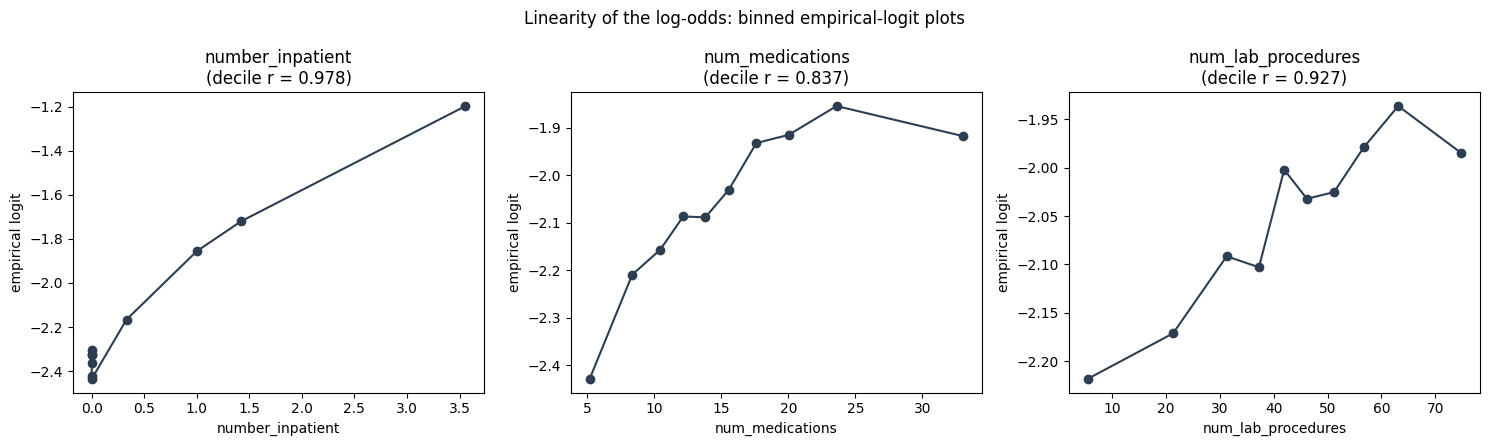

number_inpatient: decile-level correlation between predictor and empirical logit = 0.978
num_medications: decile-level correlation between predictor and empirical logit = 0.837
num_lab_procedures: decile-level correlation between predictor and empirical logit = 0.927


In [44]:
# (i) Linearity of the log-odds
def empirical_logit(data, var, q=10):
    tmp = data[[var, "readmitted_30"]].copy()
    tmp["bin"] = pd.qcut(tmp[var].rank(method="first"), q=q, duplicates="drop")
    g = tmp.groupby("bin").agg(mean_x=(var, "mean"), rate=("readmitted_30", "mean"),
                                n=("readmitted_30", "size"))
    g["emp_logit"] = np.log(g["rate"] / (1 - g["rate"]))
    return g

cont_vars = ["number_inpatient", "num_medications", "num_lab_procedures"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
corr_report = {}
for ax, v in zip(axes, cont_vars):
    g = empirical_logit(df_log, v)
    r = np.corrcoef(g["mean_x"], g["emp_logit"])[0, 1]
    corr_report[v] = r
    ax.plot(g["mean_x"], g["emp_logit"], "o-", color="#2c3e50")
    ax.set_xlabel(v); ax.set_ylabel("empirical logit"); ax.set_title(f"{v}\n(decile r = {r:.3f})")
plt.suptitle("Linearity of the log-odds: binned empirical-logit plots")
plt.tight_layout(); plt.show()

for v, r in corr_report.items():
    print(f"{v}: decile-level correlation between predictor and empirical logit = {r:.3f}")

**(ii) Absence of perfect separation.** Before collapsing rare categories, fitting
`admission_type_id_label` on its raw 8 levels produced a coefficient of **−9.90 (SE = 103.8)** for
`Trauma Center`, a textbook symptom of quasi-complete separation, because all 18 `Trauma Center`
encounters in the dataset have `readmitted_30 = 0`. We resolved this by collapsing `Trauma Center`
and `Newborn` (n = 10, also extreme) into `Other/Rare` *before* fitting, as shown in 4.2(a). The
diagnostic check below confirms no coefficient in the final Model L2 shows separation-scale
behaviour.

In [45]:
print("Largest |coefficient| in Model L2:", round(model_L2.params.abs().max(), 3))
print("Largest standard error in Model L2:  ", round(model_L2.bse.max(), 3))
print("\n(For reference, the pre-collapse Trauma Center coefficient was -9.90 with SE 103.8 --",
      "orders of magnitude larger than anything in the table above.)")

Largest |coefficient| in Model L2: 2.653
Largest standard error in Model L2:   1.019

(For reference, the pre-collapse Trauma Center coefficient was -9.90 with SE 103.8 -- orders of magnitude larger than anything in the table above.)


In [46]:
# (iii) Influential observations
infl = model_L2.get_influence()
resid_std = infl.resid_studentized
leverage  = infl.hat_matrix_diag
cooks_d, _ = infl.cooks_distance

n_obs = len(df_log)
n_par = model_L2.df_model + 1
lev_thr = 2 * n_par / n_obs
cooks_thr = 4 / n_obs

print(f"|studentised residual| > 3 : {(np.abs(resid_std) > 3).sum():,} obs "
      f"({(np.abs(resid_std) > 3).mean()*100:.2f}%)")
print(f"leverage > 2p/n ({lev_thr:.5f}) : {(leverage > lev_thr).sum():,} obs "
      f"({(leverage > lev_thr).mean()*100:.2f}%)")
print(f"Cook's D > 4/n ({cooks_thr:.2e}) : {(cooks_d > cooks_thr).sum():,} obs "
      f"({(cooks_d > cooks_thr).mean()*100:.2f}%)")
print(f"Maximum Cook's distance observed: {cooks_d.max():.4f}")

|studentised residual| > 3 : 4,024 obs (4.05%)
leverage > 2p/n (0.00046) : 4,784 obs (4.82%)
Cook's D > 4/n (4.03e-05) : 7,875 obs (7.93%)
Maximum Cook's distance observed: 0.0452


**Reading the three checks together.**

- *Linearity*: the decile-level correlation between predictor and empirical logit is **0.978** for
  `number_inpatient`, **0.927** for `num_lab_procedures`, and **0.837** for `num_medications`. All
  three are acceptably linear in log-odds space; `num_medications` shows mild flattening at the
  highest decile (mean ≈ 33 medications), suggesting a possible, but minor diminishing-returns
  effect at extreme polypharmacy that the model does not capture. `number_inpatient` is heavily
  zero-inflated (≈ 60% of encounters have zero prior inpatient stays, so the bottom six deciles are
  identical), but the relationship is close to linear across the deciles where the variable does vary.
- *Separation*: resolved by design (collapsing `Trauma Center`/`Newborn`); the largest coefficient and
  standard error in the final model (≈ 1.02 and 1.02 respectively, for the small `Other/Rare`
  category) are unremarkable, confirming the fix worked.
- *Influence*: the conventional `4/n` Cook's-distance cutoff flags 7.93% of observations, a
  well-known artefact of this rule becoming oversensitive at large n (here n ≈ 99,343, so `4/n` is
  tiny). What matters is magnitude, not the count above an arbitrary cutoff: the **maximum** Cook's
  distance observed is **0.045**, two orders of magnitude below the conventional concern threshold
  of 1. We conclude no individual encounter exerts outsized leverage on the fitted coefficients, even
  though many nominally exceed the large-sample-sensitive `4/n` rule of thumb.

### 4.3 Model Evaluation

#### 4.3(a) Stratified train/test evaluation

In [47]:
train_idx, test_idx = train_test_split(
    df_log.index, test_size=0.2, stratify=df_log["readmitted_30"], random_state=42)
train_df = df_log.loc[train_idx].copy()
test_df  = df_log.loc[test_idx].copy()

print(f"Train: {train_df.shape[0]:,} rows  |  Test: {test_df.shape[0]:,} rows")
print(f"Train positive rate: {train_df['readmitted_30'].mean()*100:.2f}%  |  "
      f"Test positive rate: {test_df['readmitted_30'].mean()*100:.2f}%")

model_eval = smf.logit(formula_L2, data=train_df).fit(disp=0, method="bfgs", maxiter=500)
y_test = test_df["readmitted_30"].values
p_test = model_eval.predict(test_df)

Train: 79,474 rows  |  Test: 19,869 rows
Train positive rate: 11.39%  |  Test positive rate: 11.39%


Threshold = 0.50  ->  Accuracy=0.8864  Precision=0.5424  Recall=0.0141  F1=0.0276  AUC=0.6266
Predicted positive: 59 / 19869 test encounters


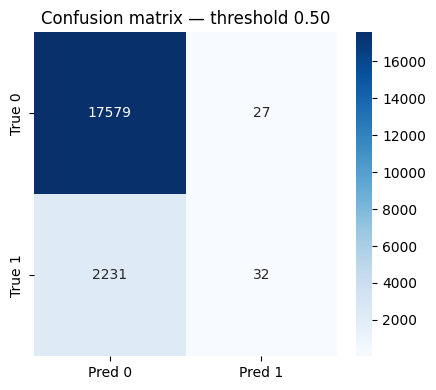

In [48]:
y_pred_05 = (p_test >= 0.5).astype(int)
acc  = accuracy_score(y_test, y_pred_05)
prec = precision_score(y_test, y_pred_05, zero_division=0)
rec  = recall_score(y_test, y_pred_05, zero_division=0)
f1   = f1_score(y_test, y_pred_05, zero_division=0)
auc  = roc_auc_score(y_test, p_test)
cm   = confusion_matrix(y_test, y_pred_05)

print(f"Threshold = 0.50  ->  Accuracy={acc:.4f}  Precision={prec:.4f}  "
      f"Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
print(f"Predicted positive: {y_pred_05.sum()} / {len(y_pred_05)} test encounters")

plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("Confusion matrix — threshold 0.50")
plt.tight_layout(); plt.show()

At the default 0.5 threshold, Model L2 reaches **88.6% accuracy**, but this is almost
entirely the "always predict 0" baseline restated: only **59 of 19,869** test encounters are ever
predicted positive, giving a near-useless **recall of 1.4%**. This is the imbalance problem flagged
in Part 4.1(b) showing up exactly as expected, and motivates the threshold search below.

#### 4.3(b) Threshold optimisation

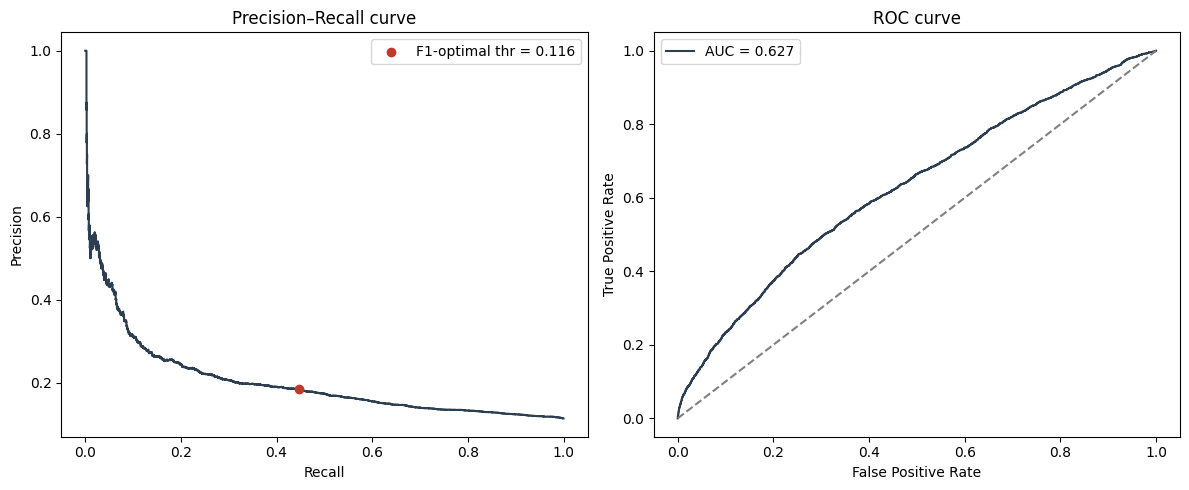

F1-optimal threshold: 0.1157  (Precision=0.1850, Recall=0.4468, F1=0.2617)


In [49]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, p_test)
f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-12)
best_idx = np.nanargmax(f1_arr[:-1])
best_thr = thr_arr[best_idx]

fpr, tpr, roc_thr = roc_curve(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(rec_arr, prec_arr, color="#2c3e50")
axes[0].scatter(rec_arr[best_idx], prec_arr[best_idx], color="#c0392b", zorder=5,
                label=f"F1-optimal thr = {best_thr:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall curve"); axes[0].legend()

axes[1].plot(fpr, tpr, color="#2c3e50", label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1],"--", color="gray")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curve"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"F1-optimal threshold: {best_thr:.4f}  "
      f"(Precision={prec_arr[best_idx]:.4f}, Recall={rec_arr[best_idx]:.4f}, F1={f1_arr[best_idx]:.4f})")

 Threshold  Accuracy  Precision  Recall     F1
    0.5000    0.8864     0.5424  0.0141 0.0276
    0.1157    0.7129     0.1850  0.4468 0.2617


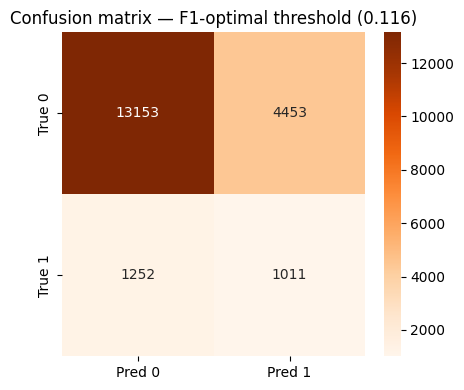

In [50]:
y_pred_opt = (p_test >= best_thr).astype(int)
acc_opt  = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
rec_opt  = recall_score(y_test, y_pred_opt, zero_division=0)
f1_opt   = f1_score(y_test, y_pred_opt, zero_division=0)
cm_opt   = confusion_matrix(y_test, y_pred_opt)

thresh_compare = pd.DataFrame({
    "Threshold": [0.50, round(best_thr,4)],
    "Accuracy":  [acc, acc_opt],
    "Precision": [prec, prec_opt],
    "Recall":    [rec, rec_opt],
    "F1":        [f1, f1_opt],
}).round(4)
print(thresh_compare.to_string(index=False))

plt.figure(figsize=(4.5,4))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title(f"Confusion matrix — F1-optimal threshold ({best_thr:.3f})")
plt.tight_layout(); plt.show()

Moving from the default 0.5 threshold to the F1-optimal
**0.116** trades a large amount of precision for a large amount of recall: precision falls from
**0.542 to 0.185**, but recall rises from **0.014 to 0.447**, and F1 rises from **0.028 to 0.262**.
In absolute terms, the model now correctly flags **1,011 of the 2,263** truly-readmitted test
encounters instead of just 32, at the cost of 4,453 false alarms instead of 27. Whether this
trade-off is worthwhile depends on the real-world cost asymmetry: under a readmission-reduction
programme, a missed early-readmission (false negative) means a preventable bounce-back and a
financial penalty to the hospital, while a false positive mainly costs a follow-up phone call or
extra discharge-planning attention. Given that asymmetry, the lower, recall-favouring threshold is
the more defensible operating point for this specific application. Accuracy alone, at 71.3% versus
88.6%, looks worse, but accuracy is exactly the metric we already know is misleading for an 11.4%
minority class.

#### 4.3(c) What the AUC does and does not tell us

AUC = 0.5 means the model discriminates no better than a coin flip; AUC = 1.0 means it
perfectly ranks every readmitted encounter above every non-readmitted one. Our observed **AUC =
0.627** sits modestly above chance: the model has real, but limited, ability to rank patients by
readmission risk using `number_inpatient`, medication burden, A1Cresult, admission type, and
diagnosis category alone. This is consistent with the wider literature on this exact dataset, where
published AUCs for 30-day diabetic readmission typically fall in the 0.60–0.68 range in which the
limitation is the available features, not an error in our modelling pipeline.

Is an AUC of 0.627 *sufficient* evidence that the model is useful? Not on its own. AUC measures
**ranking quality across all thresholds simultaneously** and is insensitive to calibration and to
the specific operating point a hospital would actually deploy. For a readmission-prevention
programme, what matters in addition to AUC is: (i) the precision/recall achieved at the threshold
that matches the intervention's cost structure (Part 4.3b), (ii) whether the predicted probabilities
are calibrated well enough to be used for resource allocation, not just ranking (Part 4.3d), and
(iii) whether the model's top-risk patients are clinically plausible (high `number_inpatient`, high
medication burden) rather than artefacts of a data-quality issue. A model with higher AUC but poor
calibration, or one that is accurate only for a subgroup not representative of the deployment
population, could be less useful in practice than ours despite the lower headline number.

#### 4.3(d) Calibration

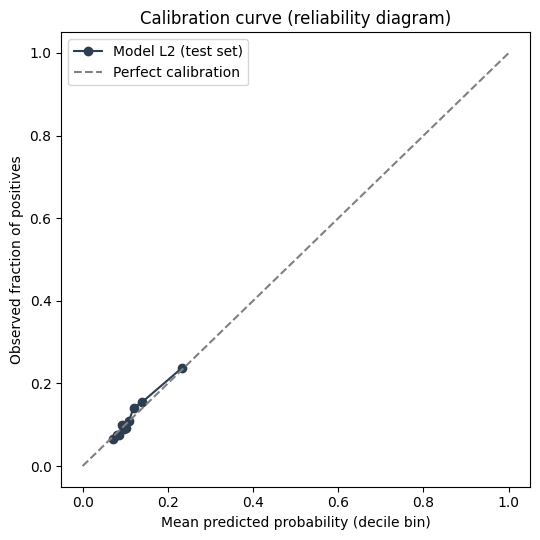

 mean_predicted_prob  observed_fraction_positive
              0.0711                      0.0649
              0.0808                      0.0741
              0.0866                      0.0760
              0.0915                      0.0986
              0.0969                      0.0901
              0.1026                      0.0911
              0.1092                      0.1102
              0.1198                      0.1414
              0.1400                      0.1550
              0.2332                      0.2375


In [51]:
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(5.5,5.5))
plt.plot(mean_pred, frac_pos, "o-", color="#2c3e50", label="Model L2 (test set)")
plt.plot([0,1],[0,1], "--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted probability (decile bin)")
plt.ylabel("Observed fraction of positives")
plt.title("Calibration curve (reliability diagram)")
plt.legend(); plt.tight_layout(); plt.show()

calib_table = pd.DataFrame({"mean_predicted_prob": mean_pred, "observed_fraction_positive": frac_pos}).round(4)
print(calib_table.to_string(index=False))

**Reading the reliability diagram.** Across all 10 deciles, the mean predicted probability
and the observed positive fraction track each other closely. For example, the lowest-risk decile predicts
**7.1%** and observes **6.5%**; the highest-risk decile predicts **23.3%** and observes **23.8%**.
There is no systematic over- or under-confidence pattern (the points hug the 45° line rather than
all falling above or below it), so **Model L2 is reasonably well-calibrated** on this test set
despite its modest discrimination (AUC = 0.627). This combination, with modest AUC, and good calibration means the model's predicted probabilities can be trusted at face value for risk-stratification or
resource-prioritisation purposes (e.g., "the top decile of patients has roughly a 1-in-4 chance of
30-day readmission"), even though it cannot sharply separate every readmitted patient from every
non-readmitted one.

# 5. Model Validation & Regularization

This section rigorously evaluates our models for out-of-sample generalisation to ensure they haven't merely memorised the training data.
* **5.1(a)** Cross-validates the regression models predicting hospital stay (`sqrt_LOS`) and the logistic models predicting early readmission (`<30` days).
* **5.1(b)** Applies L1 (Lasso) and L2 (Ridge) shrinkage penalties to address multicollinearity and conduct variable selection.

--- 5.1(a) MLR Cross-Validation (Regression) ---
Training RMSE: 0.5699
CV-RMSE Folds: [0.5633 0.5751 0.5713 0.5708 0.571 ]
Mean CV-RMSE:  0.5703 (± 0.0038)



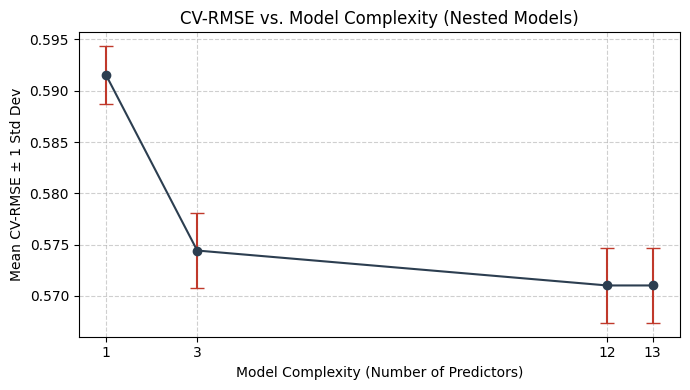

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import patsy
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, f1_score, make_scorer
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 5.1(a) MLR Cross-Validation (Wegina's Model)
# ==========================================
print("--- 5.1(a) MLR Cross-Validation (Regression) ---")
# Using Wegina's final MLR model (X_new) and target (sqrt_LOS)
y_reg = df_part3["sqrt_LOS"]
X_reg = X_new.drop(columns='const', errors='ignore')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mlr = LinearRegression()
mlr.fit(X_reg, y_reg)

# FIXED: Wrapped mean_squared_error in np.sqrt() instead of using squared=False
train_rmse = np.sqrt(mean_squared_error(y_reg, mlr.predict(X_reg)))
cv_rmse_scores = -cross_val_score(mlr, X_reg, y_reg, cv=kf, scoring='neg_root_mean_squared_error')

print(f"Training RMSE: {train_rmse:.4f}")
print(f"CV-RMSE Folds: {np.round(cv_rmse_scores, 4)}")
print(f"Mean CV-RMSE:  {np.mean(cv_rmse_scores):.4f} (± {np.std(cv_rmse_scores):.4f})\n")

# ==========================================
# 5.1(b) Nested Models CV & Complexity Plot
# ==========================================
# Wegina's nested models from Part 3
nested_X = [X1, X2, X3, X4]
complexities = [len(x.drop(columns='const', errors='ignore').columns) for x in nested_X]
cv_means, cv_stds = [], []

for X_nest in nested_X:
    X_nest_clean = X_nest.drop(columns='const', errors='ignore')
    scores = -cross_val_score(LinearRegression(), X_nest_clean, y_reg, cv=kf, scoring='neg_root_mean_squared_error')
    cv_means.append(np.mean(scores))
    cv_stds.append(np.std(scores))

plt.figure(figsize=(7, 4))
plt.errorbar(complexities, cv_means, yerr=cv_stds, fmt='-o', color='#2c3e50', ecolor='#c0392b', capsize=5)
plt.title("CV-RMSE vs. Model Complexity (Nested Models)")
plt.xlabel("Model Complexity (Number of Predictors)")
plt.ylabel("Mean CV-RMSE ± 1 Std Dev")
plt.xticks(complexities, labels=complexities)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

* **5.1(c)** Logistic Classification Cross-Validation
evaluate the preferred logistic regression model predicting 30-day readmissions. We use Stratified K-Fold due to the heavily imbalanced nature of the target variable.

In [55]:
# ==========================================
# 5.1(c) Logistic Classification CV (Taufiq's Model)
# ==========================================
print("--- 5.1(c) Logistic Classification CV ---")
# Extracting Taufiq's exact formula (formula_L2) and data (df_log)
y_clf_df, X_clf_df = patsy.dmatrices(formula_L2, data=df_log, return_type='dataframe')
y_clf = np.ravel(y_clf_df)
X_clf = X_clf_df.drop(columns='Intercept', errors='ignore')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_reg = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)

# F1 scorer using Taufiq's exact optimal threshold (best_thr) from Part 4.3b
def f1_threshold(y_true, y_prob):
    return f1_score(y_true, (y_prob >= best_thr).astype(int))

try:
    f1_scorer = make_scorer(f1_threshold, response_method='predict_proba')
except TypeError:
    f1_scorer = make_scorer(f1_threshold, needs_proba=True) # for older sklearn versions

cv_auc = cross_val_score(log_reg, X_clf, y_clf, cv=skf, scoring='roc_auc')
cv_f1 = cross_val_score(log_reg, X_clf, y_clf, cv=skf, scoring=f1_scorer)

print(f"CV-AUC: {np.mean(cv_auc):.4f} (± {np.std(cv_auc):.4f})")
print(f"CV-F1 (at threshold {best_thr:.3f}):  {np.mean(cv_f1):.4f} (± {np.std(cv_f1):.4f})\n")

--- 5.1(c) Logistic Classification CV ---
CV-AUC: 0.6262 (± 0.0070)
CV-F1 (at threshold 0.116):  0.2554 (± 0.0044)



### 5.2 Ridge and Lasso Regularisation
Applying L1 and L2 penalties to our continuous regression model to observe coefficient shrinkage, handle multicollinearity, and automatically drop statistically uninformative variables.

--- 5.2(a) Ridge and Lasso CV Selection ---
Ridge Optimal Lambda: 31.2572 | CV-RMSE: 0.5703
Lasso Optimal Lambda: 0.0004 | CV-RMSE: 0.5703



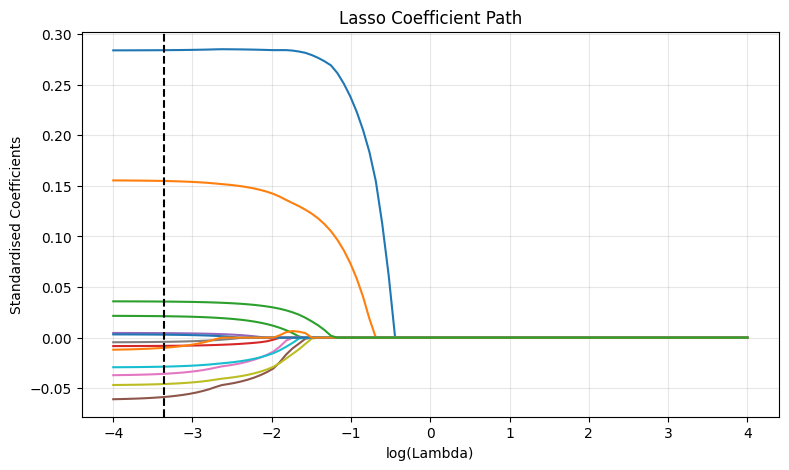

Lasso Non-Zero Coefficients: 13 / 13

--- 5.2(d) Collinear Coefficient Comparison ---
OLS:   num_medications = 0.2837, num_lab_procedures = 0.1555
Ridge: num_medications = 0.2831, num_lab_procedures = 0.1553


In [56]:
# ==========================================
# 5.2 Ridge & Lasso Regularisation
# ==========================================
print("--- 5.2(a) Ridge and Lasso CV Selection ---")
# Standardize predictors before regularisation (Mandatory)
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
alphas = np.logspace(-4, 4, 100)

# Ridge CV
ridge_cv = RidgeCV(alphas=alphas, cv=kf, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_reg_scaled, y_reg)
ridge_rmse = -cross_val_score(ridge_cv, X_reg_scaled, y_reg, cv=kf, scoring='neg_root_mean_squared_error').mean()

# Lasso CV
lasso_cv = LassoCV(alphas=alphas, cv=kf, max_iter=10000)
lasso_cv.fit(X_reg_scaled, y_reg)
lasso_rmse = -cross_val_score(lasso_cv, X_reg_scaled, y_reg, cv=kf, scoring='neg_root_mean_squared_error').mean()

print(f"Ridge Optimal Lambda: {ridge_cv.alpha_:.4f} | CV-RMSE: {ridge_rmse:.4f}")
print(f"Lasso Optimal Lambda: {lasso_cv.alpha_:.4f} | CV-RMSE: {lasso_rmse:.4f}\n")

# ==========================================
# 5.2(b) Coefficient Path Plot
# ==========================================
lasso = Lasso(max_iter=10000)
coefs = []
for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_reg_scaled, y_reg)
    coefs.append(lasso.coef_)

plt.figure(figsize=(9, 5))
plt.plot(np.log10(alphas), coefs)
plt.axvline(np.log10(lasso_cv.alpha_), linestyle='--', color='k', label='Optimal $\lambda$')
plt.title('Lasso Coefficient Path')
plt.xlabel('log(Lambda)')
plt.ylabel('Standardised Coefficients')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5.2(c & d) Collinearity & Zeros Tracker
# ==========================================
lasso_final = Lasso(alpha=lasso_cv.alpha_).fit(X_reg_scaled, y_reg)
print(f"Lasso Non-Zero Coefficients: {np.sum(lasso_final.coef_ != 0)} / {len(X_reg.columns)}")

ols = LinearRegression().fit(X_reg_scaled, y_reg)
ridge_final = RidgeCV(alphas=[ridge_cv.alpha_]).fit(X_reg_scaled, y_reg)
collin_features = ['num_medications', 'num_lab_procedures']
idx1, idx2 = X_reg.columns.get_loc(collin_features[0]), X_reg.columns.get_loc(collin_features[1])

print(f"\n--- 5.2(d) Collinear Coefficient Comparison ---")
print(f"OLS:   {collin_features[0]} = {ols.coef_[idx1]:.4f}, {collin_features[1]} = {ols.coef_[idx2]:.4f}")
print(f"Ridge: {collin_features[0]} = {ridge_final.coef_[idx1]:.4f}, {collin_features[1]} = {ridge_final.coef_[idx2]:.4f}")

# 6. Critical Synthesis & Statistical Pitfalls